# Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

In [ ]:
# Read the CSV file into a DataFrame
crsp = pd.read_csv('/content/drive/MyDrive/Quant/crsp_monthly_returns.csv')
ccm = pd.read_csv("/content/drive/MyDrive/Quant/ccm_quarterly_financials.csv")

#crsp = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Quant/crsp_monthly_returns.csv')
#ccm = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/Quant/ccm_quarterly_financials.csv")

In [ ]:
#crsp

In [ ]:
# number of unique stocks
crsp['TICKER'].nunique()

20210

# Data Cleaning

In [ ]:
# convert date
crsp['date'] = pd.to_datetime(crsp['date'], format='mixed', errors='coerce')

#rename permno for merging later
crsp = crsp.rename(columns={'PERMNO': 'permno'})

# sort
crsp = crsp.sort_values(['permno', 'date'])

# fix returns (include delisting returns)
crsp['RET'] = pd.to_numeric(crsp['RET'], errors='coerce')
crsp['DLRET'] = pd.to_numeric(crsp['DLRET'], errors='coerce')

crsp['ret_adj'] = (1 + crsp['RET'].fillna(0)) * (1 + crsp['DLRET'].fillna(0)) - 1

# price filter (use absolute value)
crsp['PRC'] = crsp['PRC'].abs()

crsp = crsp[crsp['PRC'] >= 5]

# market cap (optional but useful)
# SHROUT = shares outstanding in thousands
crsp['mktcap'] = crsp['PRC'] * crsp['SHROUT'] * 1000

crsp.head()

,permno,date,SHRCD,EXCHCD,TICKER,PERMCO,CUSIP,DLRET,PRC,RET,SHROUT,vwretd,ewretd,sprtrn,ret_adj,mktcap
0,10001,1990-01-31,11,3,GFGC,7953,36720410,NaN,9.9375,-0.018519,1022.0,-0.070114,-0.046408,-0.068817,-0.018519,10156125.0
1,10001,1990-02-28,11,3,GFGC,7953,36720410,NaN,9.8750,-0.006289,1022.0,0.014900,0.015434,0.008539,-0.006289,10092250.0
2,10001,1990-03-30,11,3,GFGC,7953,36720410,NaN,9.8750,0.012658,1027.0,0.024148,0.021315,0.024255,0.012658,10141625.0
3,10001,1990-04-30,11,3,GFGC,7953,36720410,NaN,9.8750,0.000000,1027.0,-0.028283,-0.028116,-0.026887,0.000000,10141625.0
4,10001,1990-05-31,11,3,GFGC,7953,36720410,NaN,9.7500,-0.012658,1027.0,0.088935,0.045673,0.091989,-0.012658,10013250.0


In [ ]:
ccm['datadate'] = pd.to_datetime(ccm['datadate'])

# Rename LPERMNO to permno
ccm = ccm.rename(columns={'LPERMNO': 'permno'})

# sort
ccm = ccm.sort_values(['permno', 'datadate'])

ccm.head()

,GVKEY,LINKPRIM,LINKTYPE,permno,LPERMCO,LINKDT,LINKENDDT,datadate,fyearq,fqtr,tic,atq,ltq,niq,saleq,oancfy,sic
251809,12994,P,LC,10001,7953,1986-01-09,2017-08-31,1990-03-31,1990,3,EGAS,20.245,13.002,0.728,8.350,NaN,4924
251810,12994,P,LC,10001,7953,1986-01-09,2017-08-31,1990-06-30,1990,4,EGAS,18.881,11.702,0.035,4.379,NaN,4924
251811,12994,P,LC,10001,7953,1986-01-09,2017-08-31,1990-09-30,1991,1,EGAS,18.403,11.526,-0.322,2.403,NaN,4924
251812,12994,P,LC,10001,7953,1986-01-09,2017-08-31,1990-12-31,1991,2,EGAS,21.710,14.256,0.678,8.495,NaN,4924
251813,12994,P,LC,10001,7953,1986-01-09,2017-08-31,1991-03-31,1991,3,EGAS,21.068,13.014,0.744,8.452,NaN,4924


In [ ]:
#lag total assets because we want to compare accurals over the quarter to the company's state at beg of quarter
ccm['atq_lag'] = ccm.groupby('permno')['atq'].shift(1)

#compute quartely cash flows from YTD cash flows
ccm['fyear'] = ccm['datadate'].dt.year


#calculate quarterly operating cash flow
ccm['oancfq_est'] = ccm.groupby('permno')['oancfy'].diff()
# fill Q1 values
ccm.loc[ccm['oancfq_est'].isna(), 'oancfq_est'] = ccm['oancfy']

#alt way of calculating quarterly cf to test feature robustness
#ccm['oancfq_est'] = ccm['oancfy']/4


#compute accurals
ccm['accruals'] = (ccm['niq'] - ccm['oancfq_est']) / ccm['atq_lag']

#winsorize outliters
def winsorize(series, p=0.01):
    lower = series.quantile(p)
    upper = series.quantile(1-p)
    return series.clip(lower, upper)

ccm['accruals'] = winsorize(ccm['accruals'])


#apply reporting lag because company financials are released at end of the quarter
ccm['signal_date'] = ccm['datadate'] + pd.DateOffset(months=3)

#drop bad rows
ccm = ccm.dropna(subset=['accruals', 'atq_lag'])
ccm = ccm[np.isfinite(ccm['accruals'])]
ccm = ccm[(ccm['atq_lag'] > 0)]

In [ ]:
#ccm

# Merge CCM with CRSP

In [ ]:
ccm = ccm[['permno', 'signal_date', 'accruals']]

ccm = ccm.sort_values(['permno', 'signal_date'])

merged = pd.merge_asof(
    crsp.sort_values('date'),
    ccm.sort_values('signal_date'),
    left_on='date',
    right_on='signal_date',
    by='permno',
    direction='backward'
)

In [ ]:
merged = merged.dropna(subset=['accruals'])
merged

,permno,date,SHRCD,EXCHCD,TICKER,PERMCO,CUSIP,DLRET,PRC,RET,SHROUT,vwretd,ewretd,sprtrn,ret_adj,mktcap,signal_date,accruals
21189,60548,1990-07-31,11,2,MPR,3023,59087630,NaN,20.00000,-0.157895,2911.0,-0.009392,-0.025731,-0.005223,-0.157895,5.822000e+07,1990-07-30,-0.003729
21199,80179,1990-07-31,11,3,VALU,5974,92043710,NaN,18.25000,-0.109756,9958.0,-0.009392,-0.025731,-0.005223,-0.109756,1.817335e+08,1990-07-30,0.002699
21226,53495,1990-07-31,11,2,KPI,21054,49412510,NaN,5.00000,0.000000,1429.0,-0.009392,-0.025731,-0.005223,0.000000,7.145000e+06,1990-07-30,-0.010731
21229,10514,1990-07-31,11,3,TWMC,8431,48583710,NaN,31.25000,0.000000,9058.0,-0.009392,-0.025731,-0.005223,0.000000,2.830625e+08,1990-07-30,0.279034
21230,13777,1990-07-31,11,3,AMSWA,5828,02968310,NaN,14.12500,-0.181159,17286.0,-0.009392,-0.025731,-0.005223,-0.181159,2.441648e+08,1990-07-30,-0.004086
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1551922,20391,2024-12-31,11,1,TPL,57695,88262P10,NaN,1105.95996,-0.307814,22975.0,-0.031582,-0.021978,-0.024990,-0.307814,2.540943e+10,2024-12-30,-0.009096
1551923,20365,2024-12-31,11,1,BODI,57540,07346330,NaN,6.15000,-0.042056,4195.0,-0.031582,-0.021978,-0.024990,-0.042056,2.579925e+07,2024-12-30,-0.053417
1551924,20357,2024-12-31,11,1,IONQ,57538,46222L10,NaN,41.77000,0.144384,216392.0,-0.031582,-0.021978,-0.024990,0.144384,9.038694e+09,2024-12-30,-0.064327
1551925,20567,2024-12-31,11,3,ELTX,57905,28657F10,NaN,5.10000,0.001965,10791.0,-0.031582,-0.021978,-0.024990,0.001965,5.503410e+07,2024-12-30,-0.610797


# Portfolio Construction

In [ ]:
#extract year
merged['year'] = merged['date'].dt.year

#get signal in June of each year
formation = merged[merged['date'].dt.month == 6]

#rank stocks into quintiles
formation['rank'] = formation.groupby('year')['accruals'].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')
)

/tmp/ipykernel_1419/3029208109.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  formation['rank'] = formation.groupby('year')['accruals'].transform(


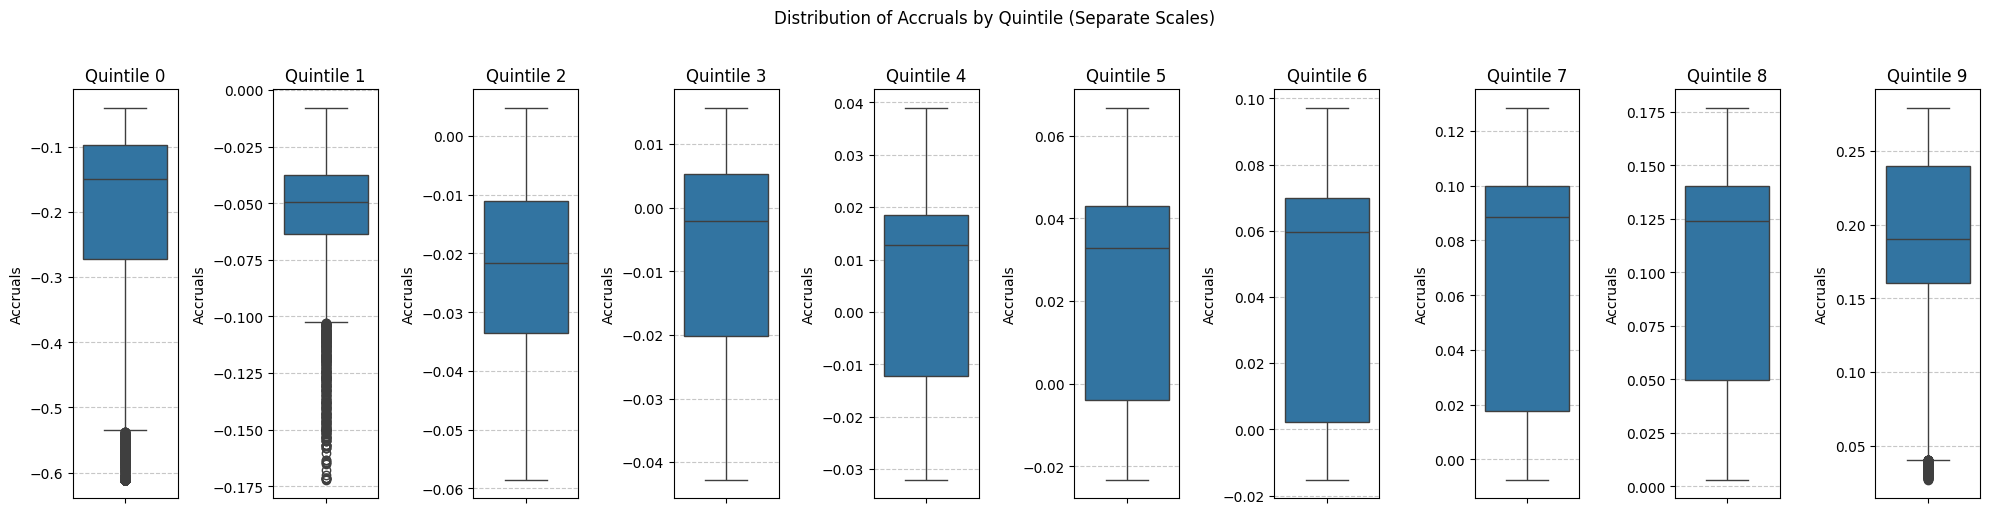

In [ ]:
fig, axes = plt.subplots(1, 10, figsize=(20, 5), sharey=False)

for i in range(10):
    sns.boxplot(y='accruals', data=formation[formation['rank'] == i], ax=axes[i])
    axes[i].set_title(f'Quintile {i}')
    axes[i].set_xlabel('') # Remove x-label as it's just the quintile number
    axes[i].set_ylabel('Accruals')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Distribution of Accruals by Quintile (Separate Scales)', y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1419/1835237672.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  formation.loc[:, 'decade'] = (formation['year'] // 10) * 10


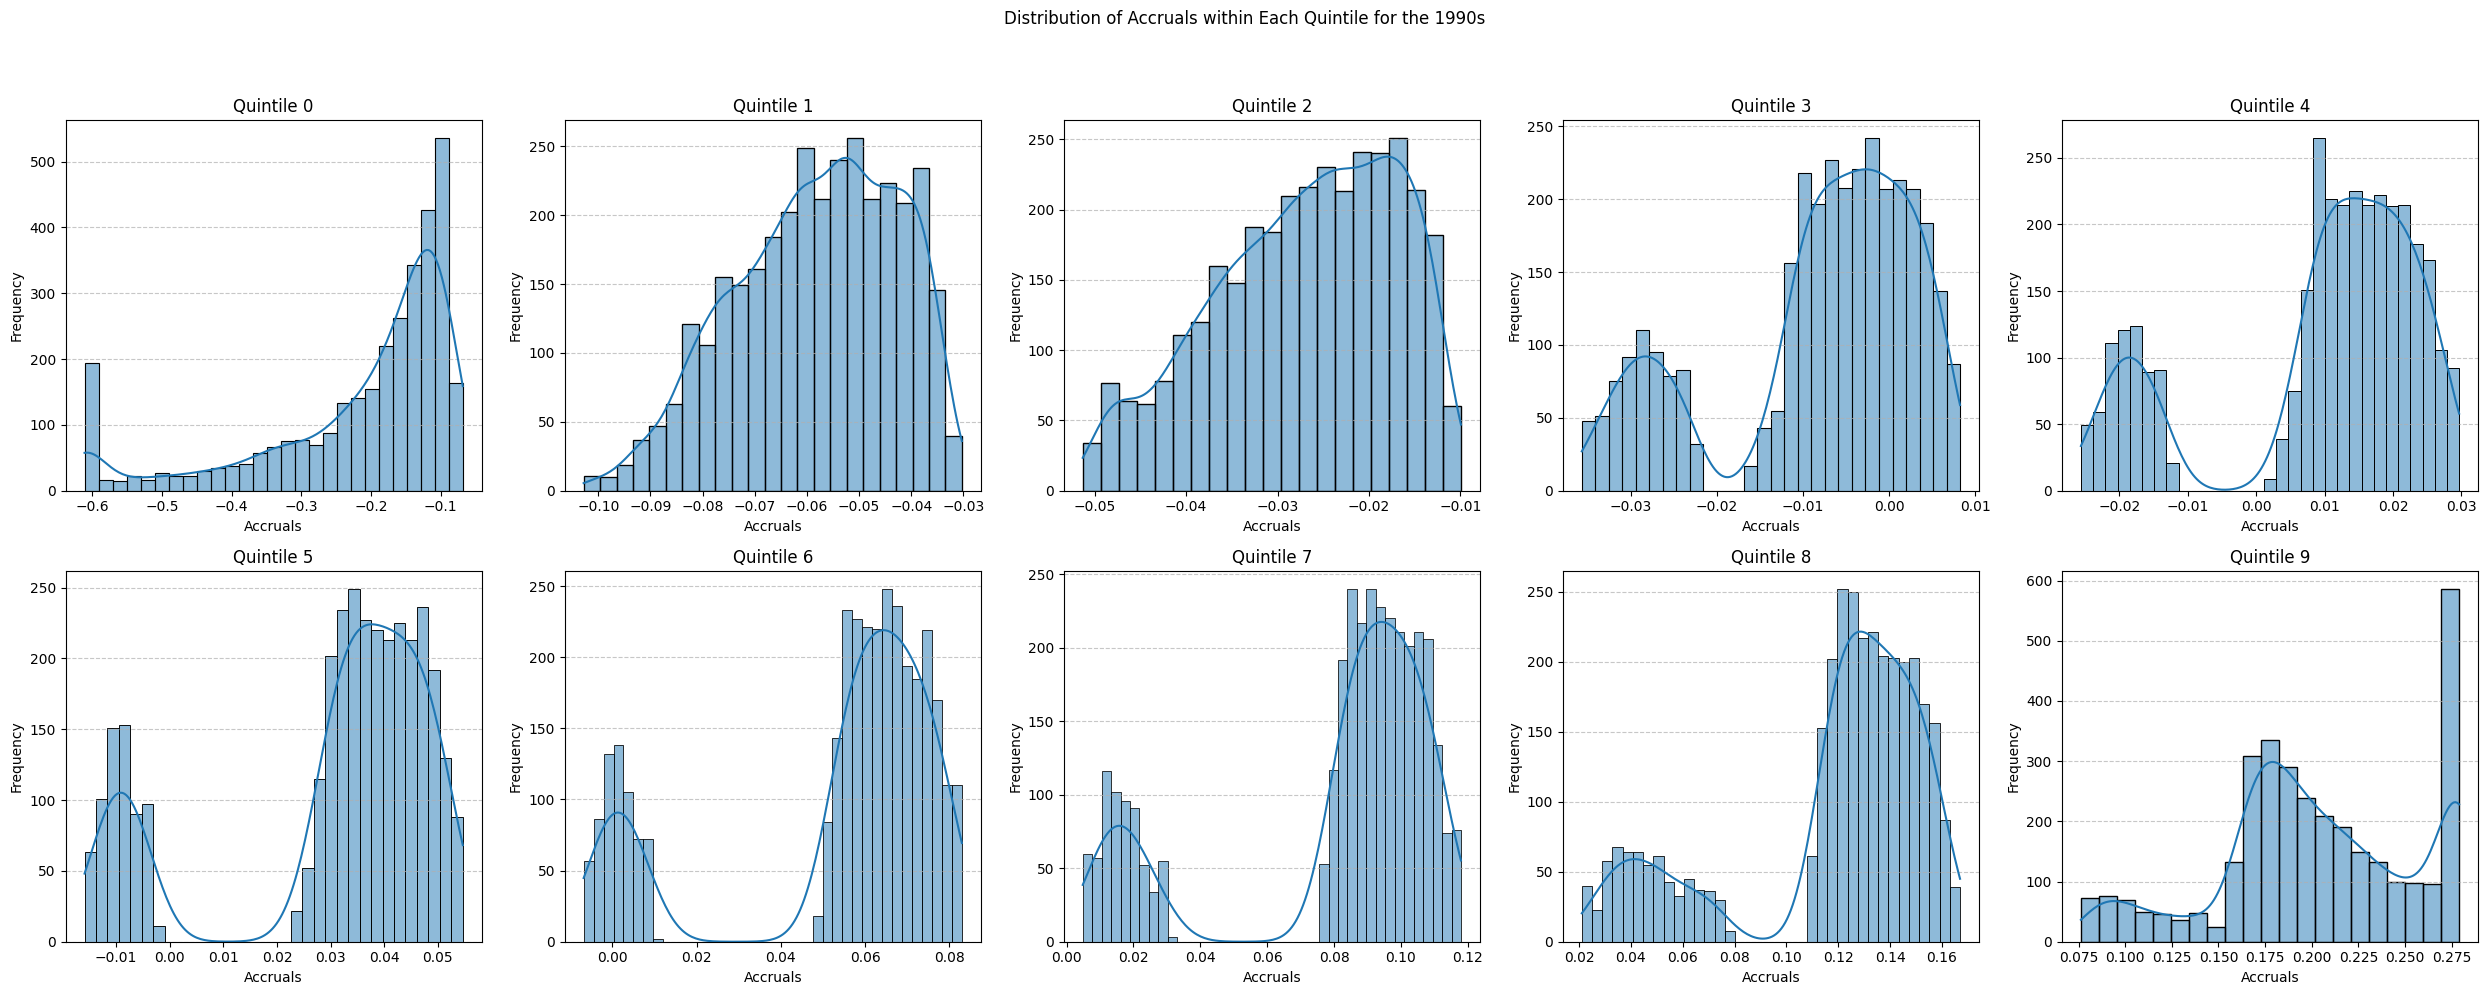

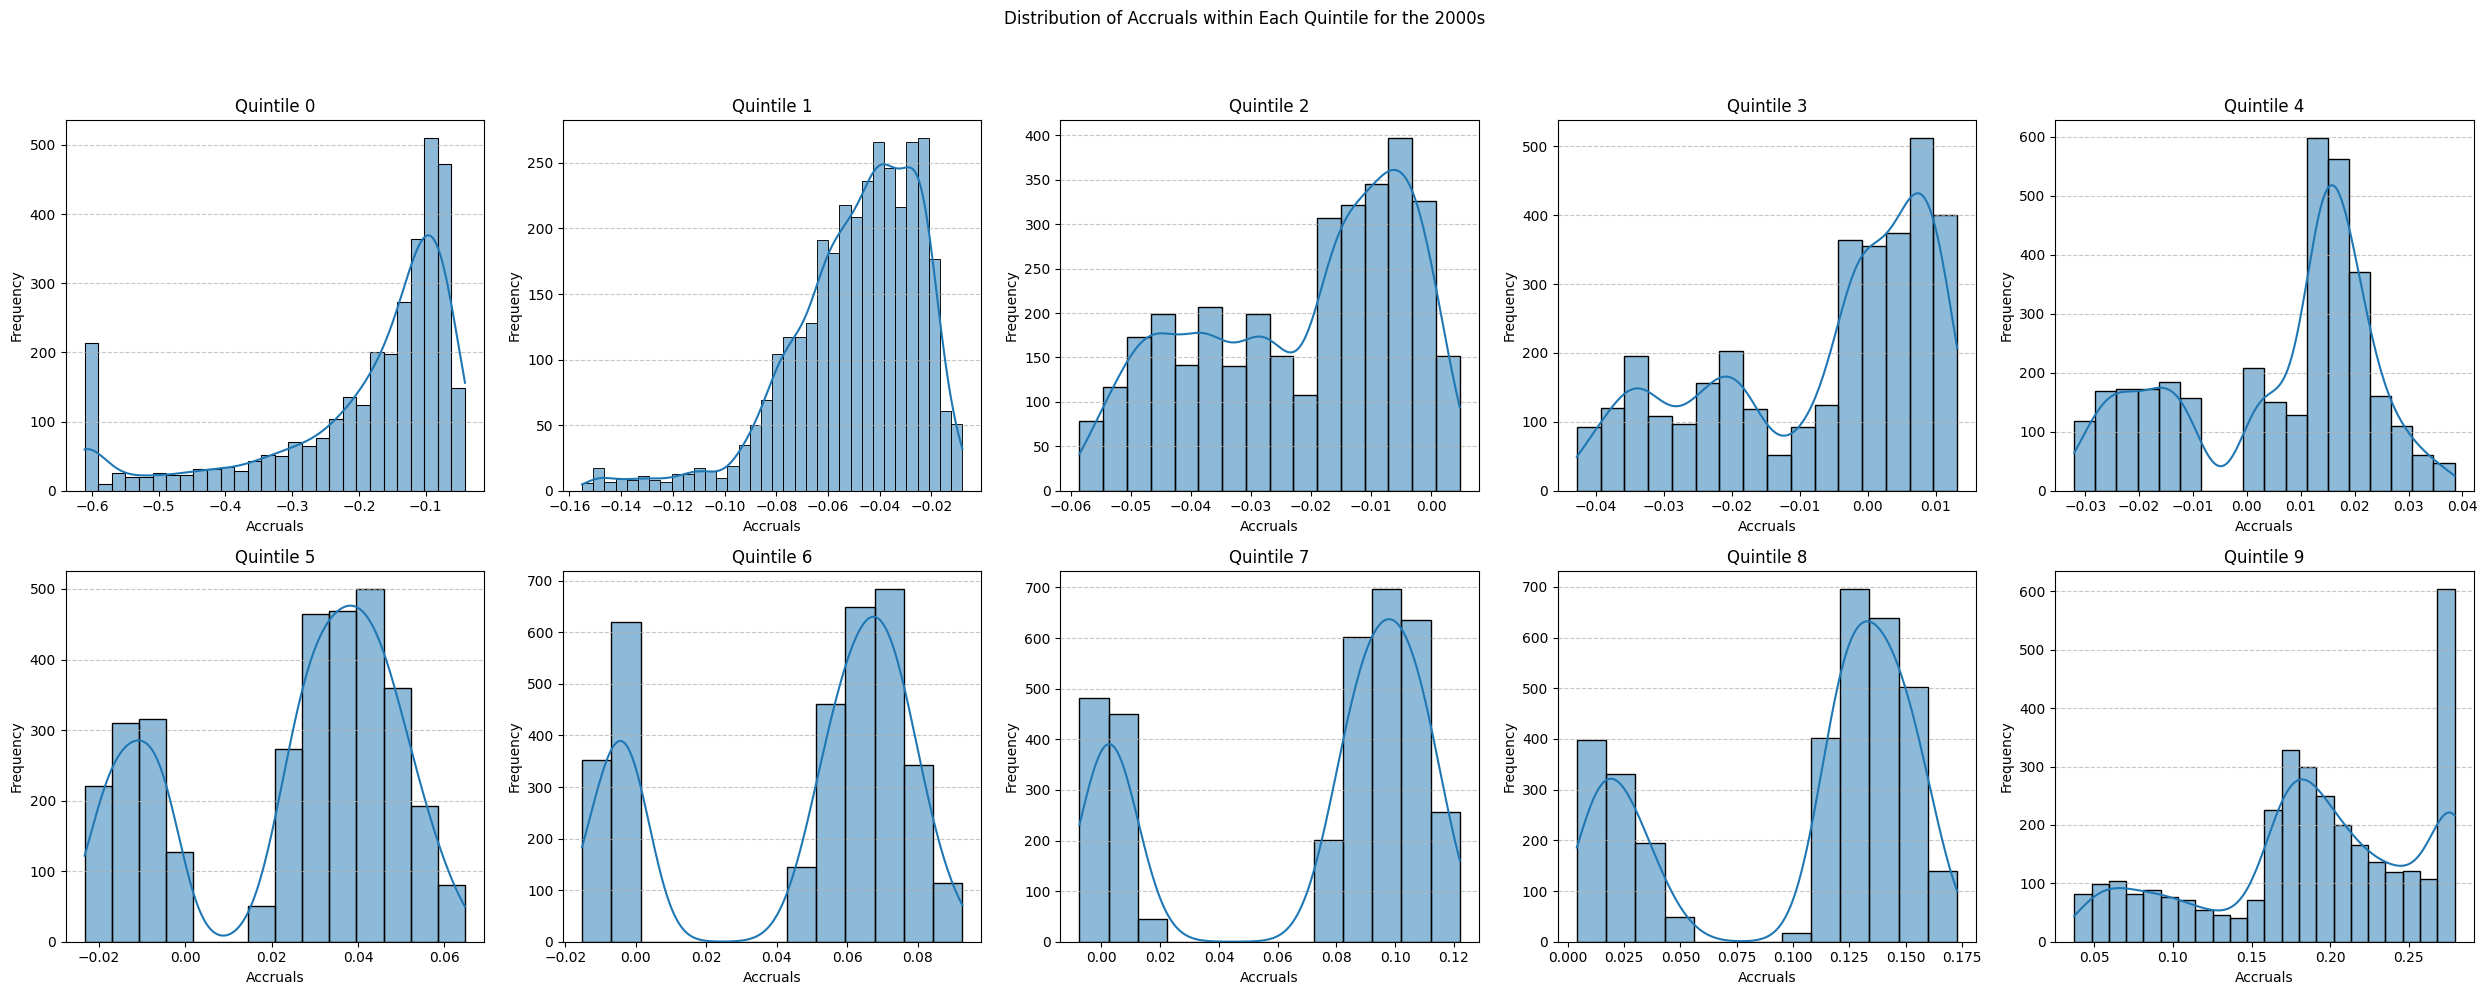

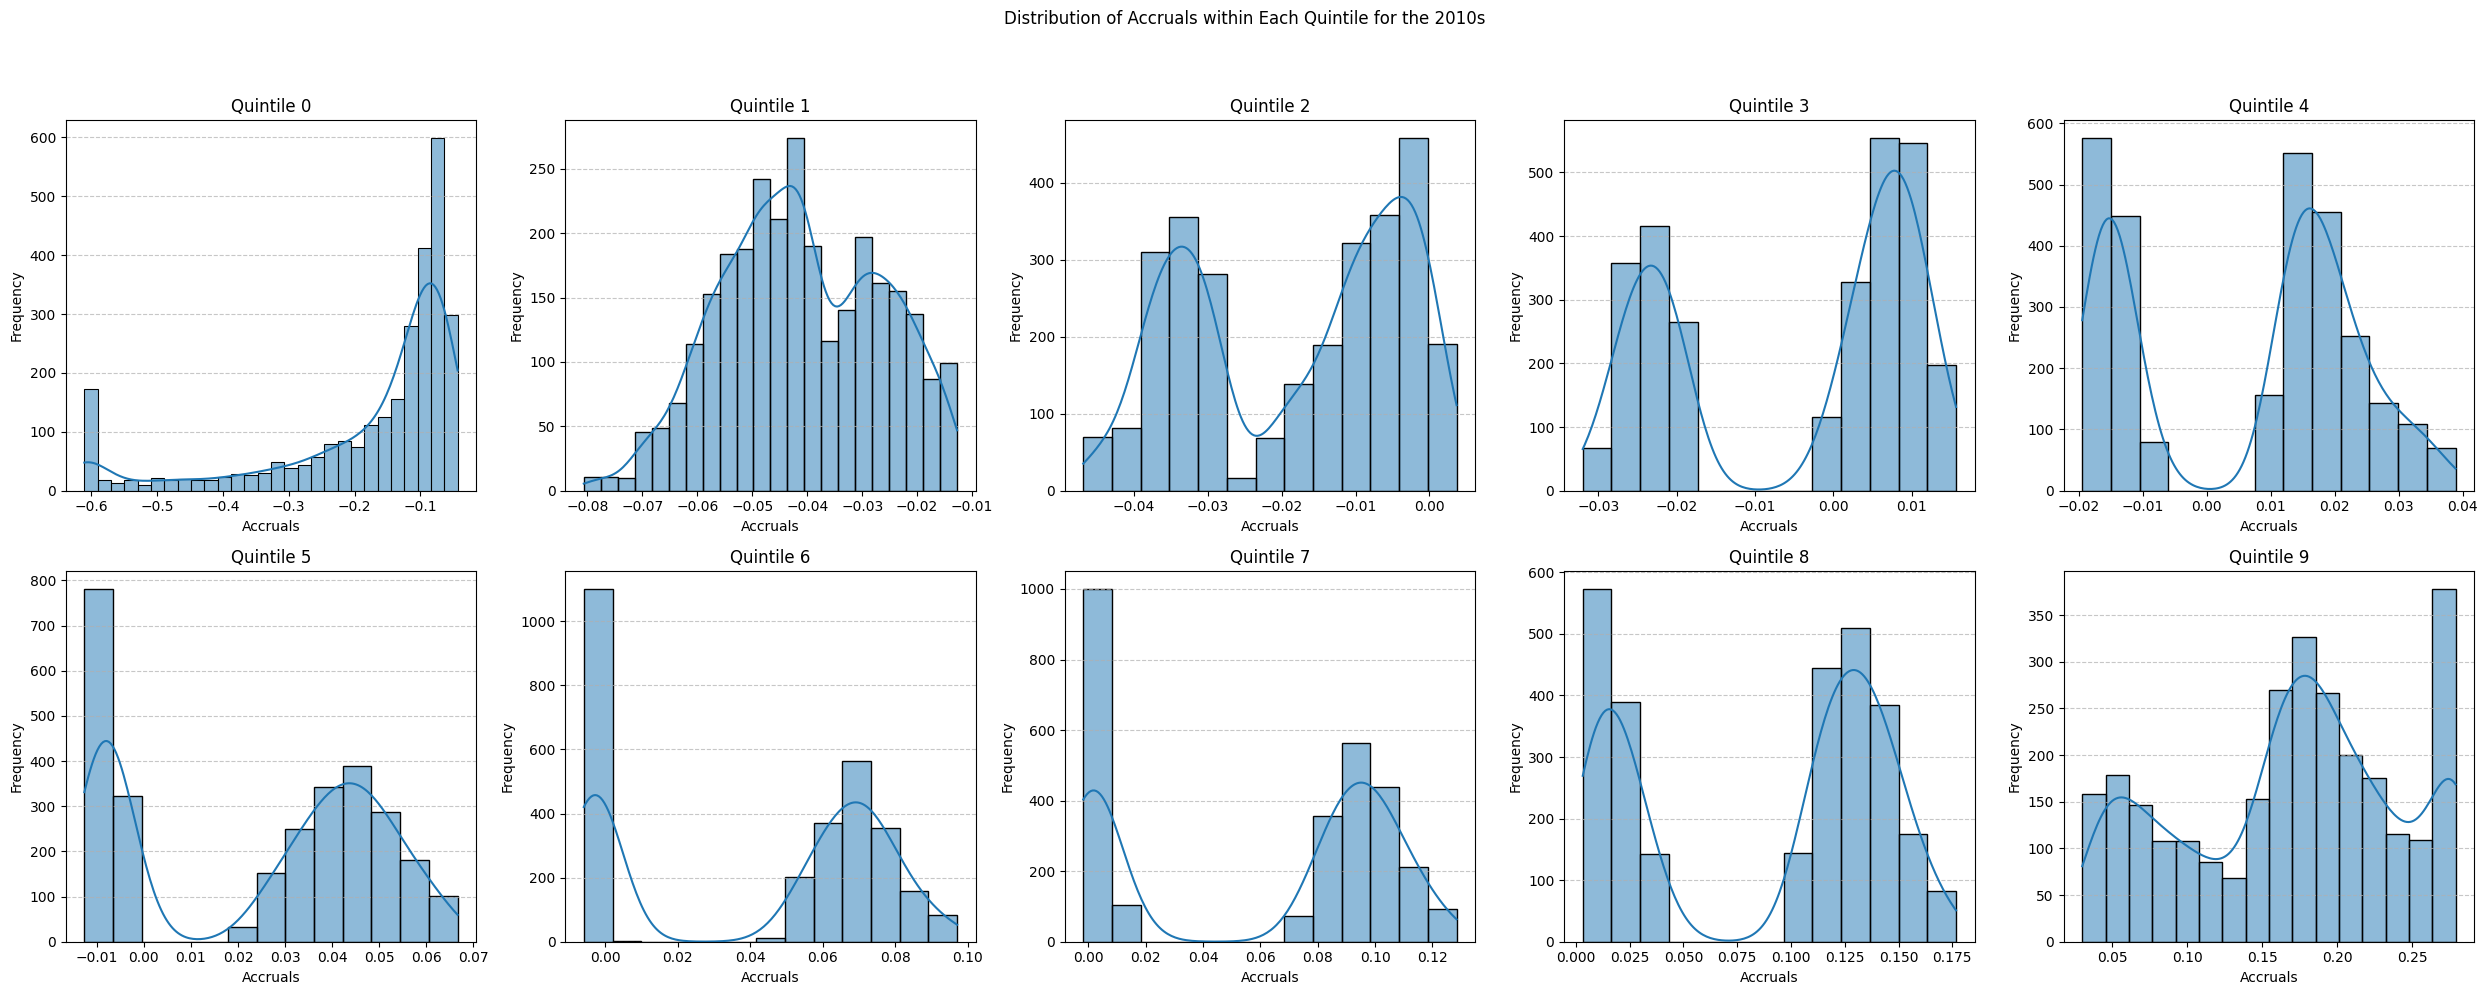

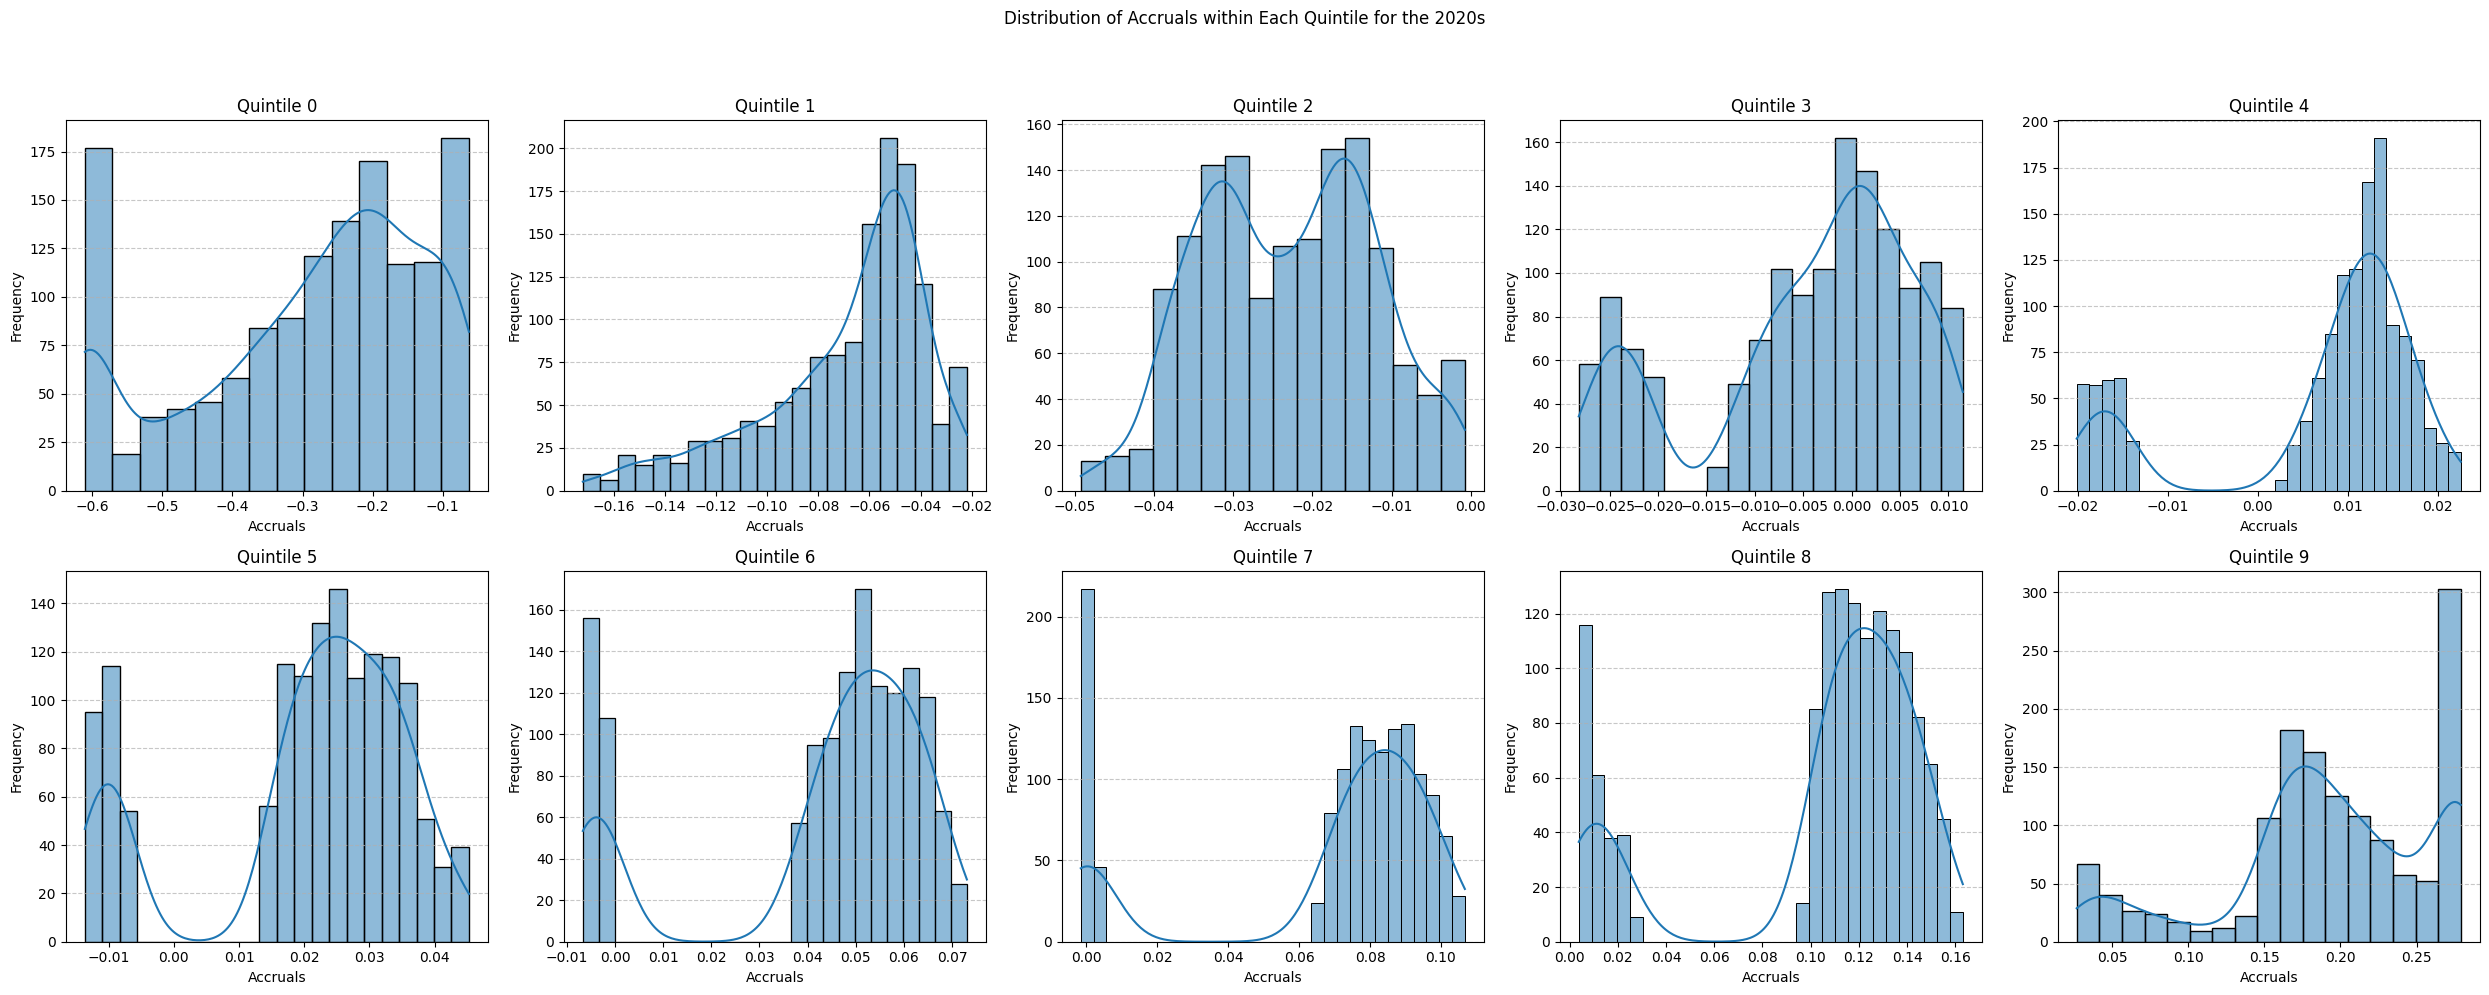

In [ ]:
formation.loc[:, 'decade'] = (formation['year'] // 10) * 10

unique_decades = sorted(formation['decade'].unique())

for decade in unique_decades:
    decade_data = formation[formation['decade'] == decade]

    # Create a figure with 2 rows and 5 columns for 10 quintiles
    fig, axes = plt.subplots(2, 5, figsize=(25, 10), sharey=False)
    axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

    for i in range(10):
        quintile_data = decade_data[decade_data['rank'] == i]['accruals']
        if not quintile_data.empty:
            # Removed fixed 'bins=50' to let Seaborn automatically determine optimal bin size
            sns.histplot(quintile_data, kde=True, ax=axes[i])
            axes[i].set_title(f'Quintile {i}')
            axes[i].set_xlabel('Accruals')
            axes[i].set_ylabel('Frequency')
            axes[i].grid(axis='y', linestyle='--', alpha=0.7)
        else:
            axes[i].set_title(f'Quintile {i} (No Data)')
            axes[i].set_visible(False) # Optionally hide empty subplots

    plt.suptitle(f'Distribution of Accruals within Each Quintile for the {decade}s', y=1.02)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
    plt.show()

#### Distribution of market caps by each quintile by decade

/tmp/ipykernel_1419/2823649349.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  formation.loc[:, 'log10_mktcap'] = np.log10(formation['mktcap'].dropna())


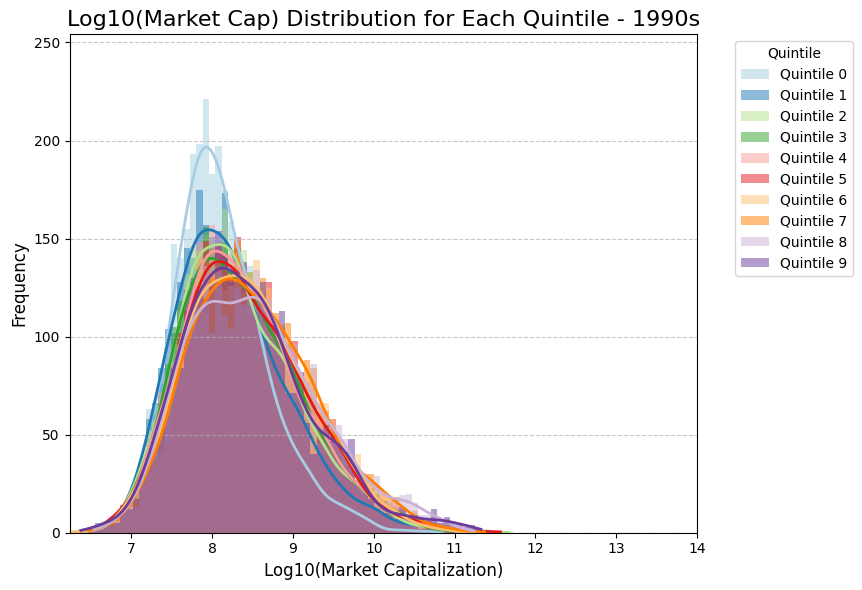

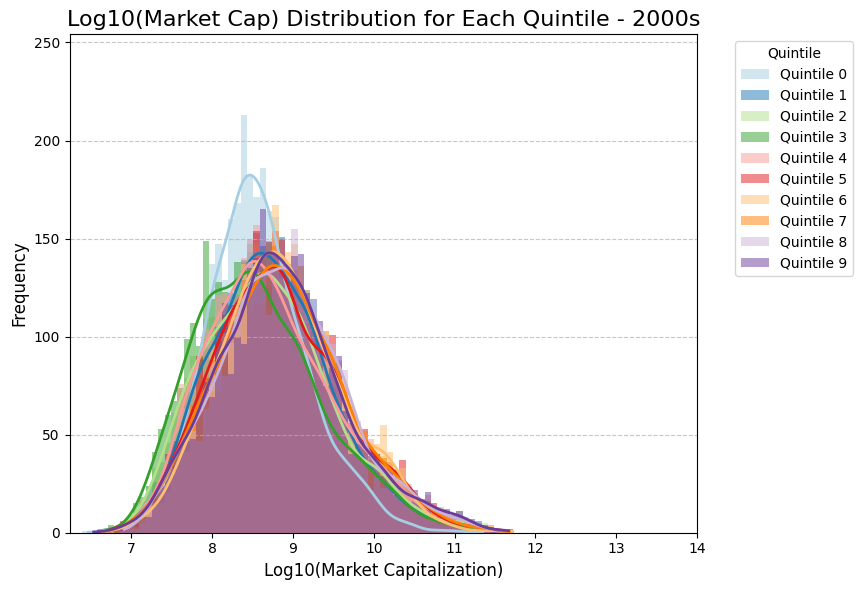

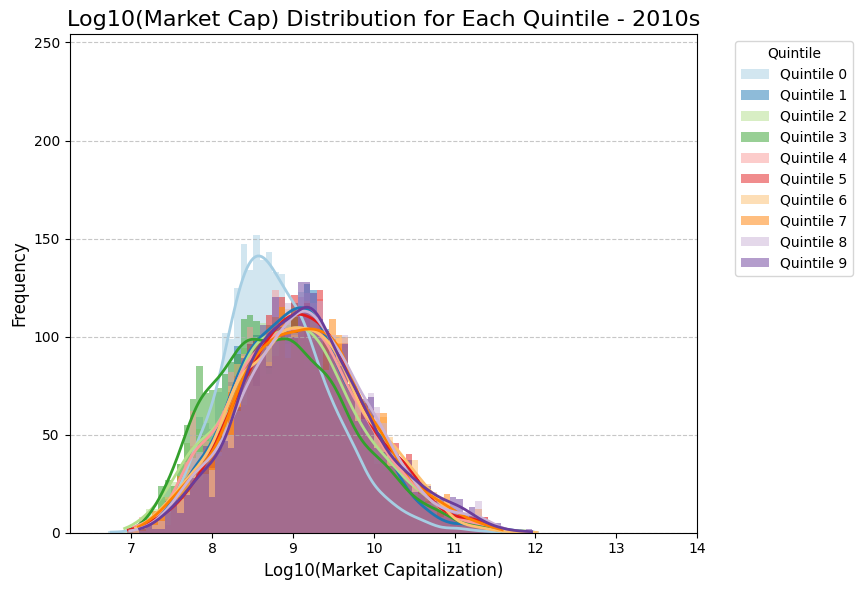

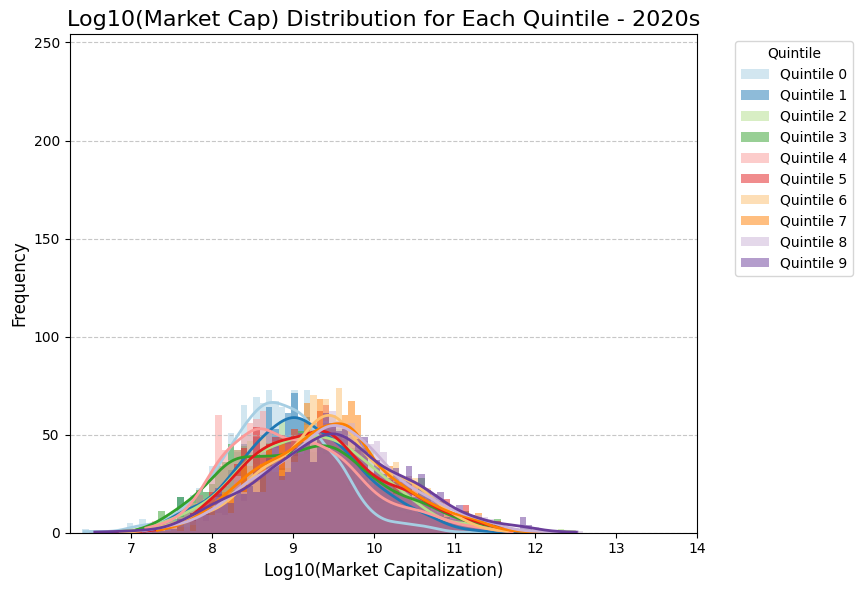

In [ ]:
# Ensure 'decade' and 'rank' are already computed in 'formation'
# These were computed in previous cells:
# formation.loc[:, 'decade'] = (formation['year'] // 10) * 10
# formation['rank'] = formation.groupby('year')['accruals'].transform(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop'))

# Calculate log10(mktcap)
formation.loc[:, 'log10_mktcap'] = np.log10(formation['mktcap'].dropna())

# Get overall min and max for log10_mktcap to set consistent x-axis limits
# Set a floor for market cap at 1 million, which is log10(1e6) = 6
global_log10_mktcap_min = max(formation['log10_mktcap'].min(), 6.0)
# Set max x-value to 14 as per previous user request for overall market cap plots
global_log10_mktcap_max = 14.0

# Define a common set of bins for histograms across all plots for consistent frequency calculation
num_bins = 100  # A reasonable number of bins
bins = np.linspace(global_log10_mktcap_min, global_log10_mktcap_max, num_bins)

global_max_frequency = 0

# Determine the global maximum frequency across all quintiles and decades for consistent y-axis scaling
for decade in sorted(formation['decade'].unique()):
    decade_data = formation[formation['decade'] == decade]
    for i in range(10):  # For each quintile
        quintile_data = decade_data[decade_data['rank'] == i]['log10_mktcap'].dropna()
        if not quintile_data.empty:
            counts, _ = np.histogram(quintile_data, bins=bins)
            if counts.max() > global_max_frequency:
                global_max_frequency = counts.max()

# Add a little padding to the global_max_frequency for better visualization
y_padding = global_max_frequency * 0.15  # 15% padding
global_max_frequency += y_padding

# Now, iterate and plot for each decade
unique_decades = sorted(formation['decade'].unique())

for decade in unique_decades:
    decade_data = formation[formation['decade'] == decade]

    plt.figure(figsize=(10, 6))  # Adjusted figure size

    # Generate a color palette for the 10 quintiles
    colors = sns.color_palette("Paired", 10)

    for i in range(10):  # For each quintile
        quintile_data = decade_data[decade_data['rank'] == i]['log10_mktcap'].dropna()

        if not quintile_data.empty:
            sns.histplot(
                quintile_data,
                bins=bins,  # Use the globally defined bins for consistent comparison
                kde=True,  # Now includes the best fit line
                stat='count',  # Plot frequency count
                color=colors[i],
                alpha=0.5,  # Reduce bar alpha to emphasize KDE lines and reduce clutter
                label=f'Quintile {i}',
                edgecolor='none',
                line_kws={'linewidth': 2, 'alpha': 1} # Make KDE line opaque and thicker
            )

    plt.title(f'Log10(Market Cap) Distribution for Each Quintile - {decade}s', fontsize=16)
    plt.xlabel('Log10(Market Capitalization)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.xlim(global_log10_mktcap_min, global_log10_mktcap_max)
    plt.ylim(0, global_max_frequency)
    plt.legend(title='Quintile', bbox_to_anchor=(1.05, 1), loc='upper left')  # Place legend outside
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout(rect=[0, 0, 0.88, 1])  # Adjust layout to make space for legend
    plt.show()

#### Overall Distribution of Log10(Market Capitalization) by Decade


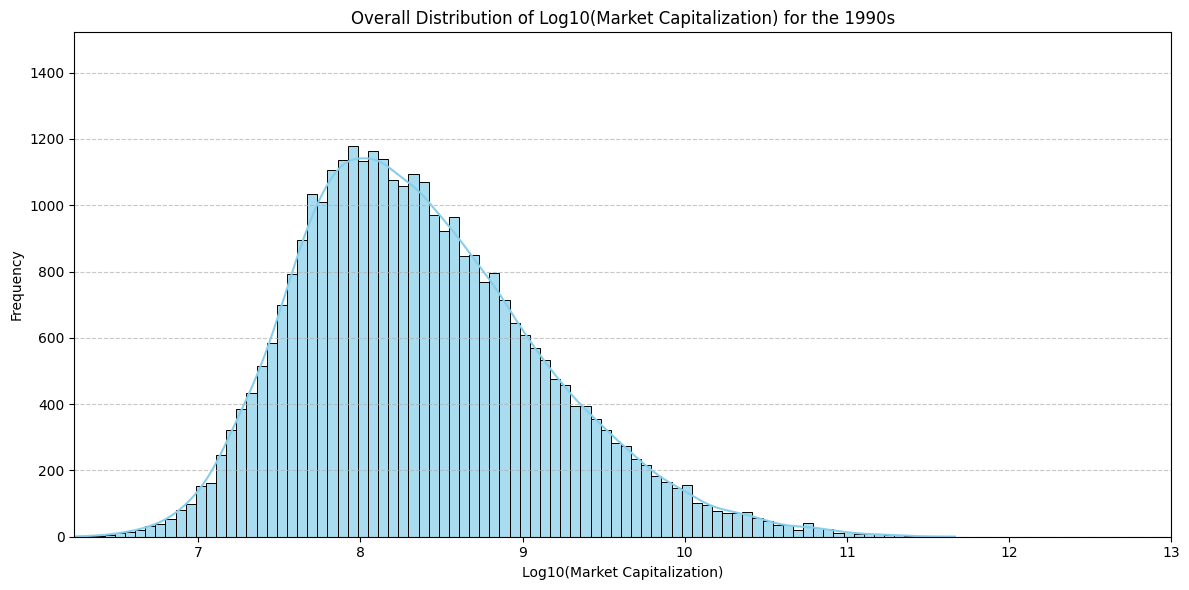

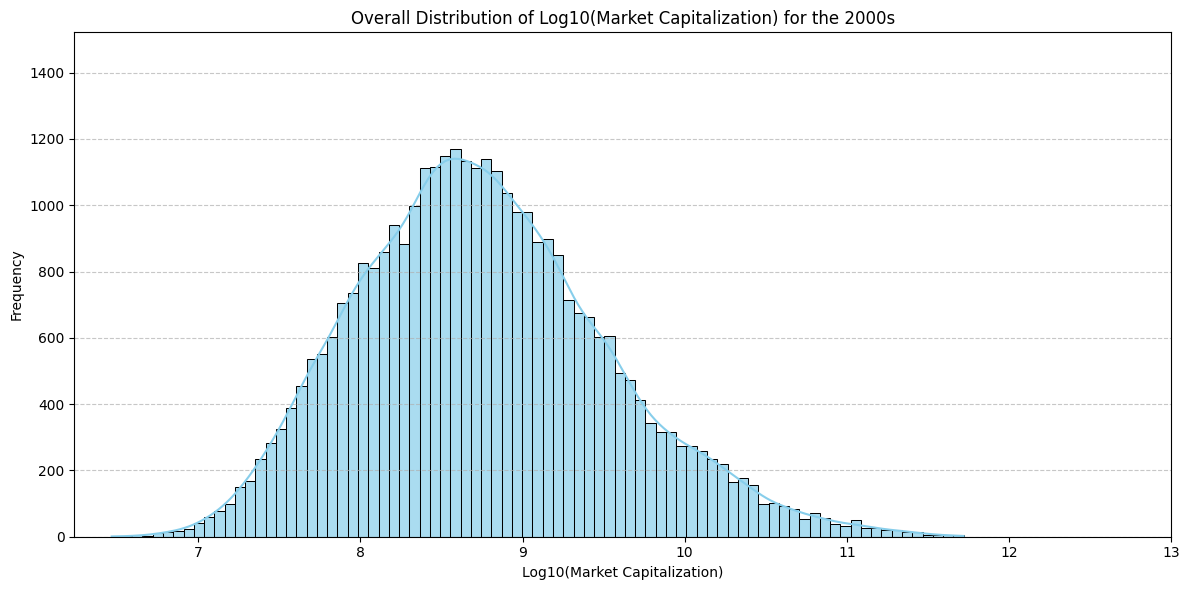

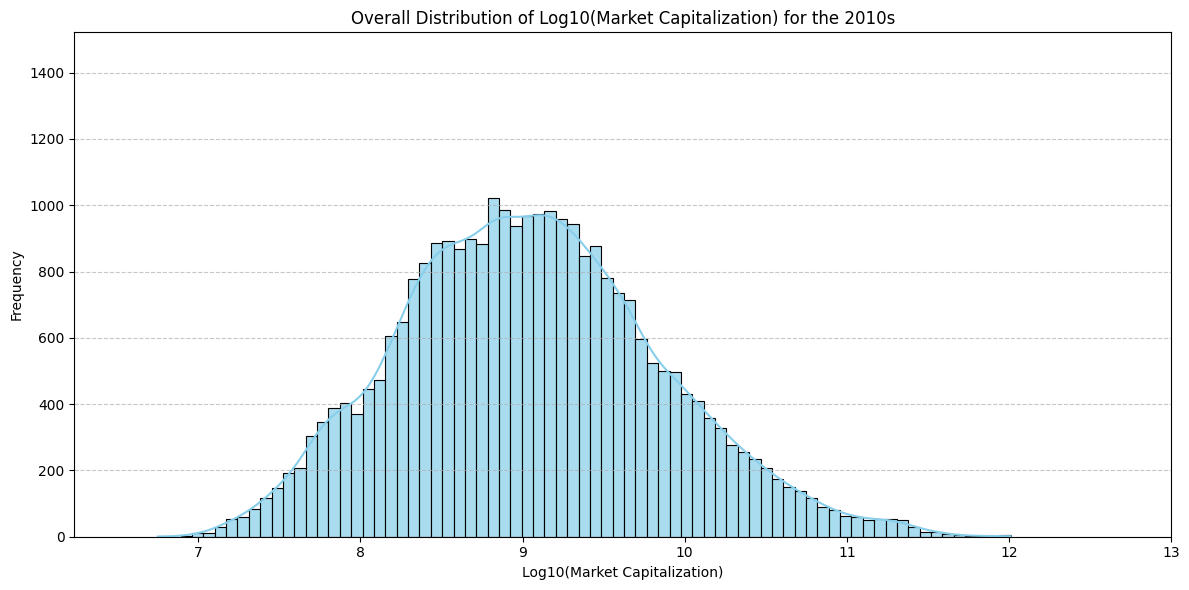

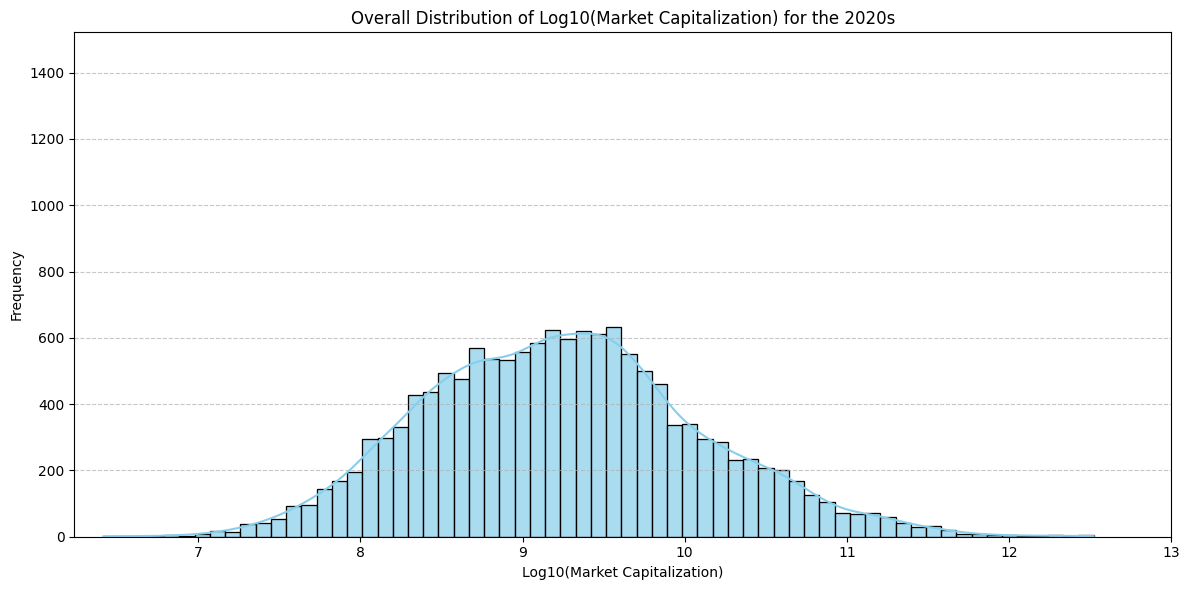

In [ ]:
# Recalculate a separate max frequency for the overall distribution to ensure the axis fits
overall_max_frequency = 0
for decade in unique_decades:
    decade_data = formation[formation['decade'] == decade]
    mktcap_data = np.log10(decade_data['mktcap'].dropna())
    counts, _ = np.histogram(mktcap_data, bins=num_bins, range=(global_log10_mktcap_min, 13.0))
    if counts.max() > overall_max_frequency:
        overall_max_frequency = counts.max()

# Add padding
adjusted_overall_max_y = overall_max_frequency * 1.2

for decade in unique_decades:
    decade_data = formation[formation['decade'] == decade]

    # Create a single figure and axis for the overall distribution within this decade
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot the histogram for all stocks in the decade, using log10 market cap
    sns.histplot(np.log10(decade_data['mktcap'].dropna()), kde=True, ax=ax, color='skyblue', alpha=0.7)

    ax.set_title(f'Overall Distribution of Log10(Market Capitalization) for the {decade}s')
    ax.set_xlabel('Log10(Market Capitalization)')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Apply the corrected limits
    adjusted_global_log_mktcap_min = max(global_log10_mktcap_min, 6.0)
    adjusted_global_log_mktcap_max = 13.0

    ax.set_xlim(adjusted_global_log_mktcap_min, adjusted_global_log_mktcap_max)
    ax.set_ylim(0, adjusted_overall_max_y)

    plt.tight_layout()
    plt.show()

In [ ]:
# number of public companies has decreased since peak in mid 1990s
stocks_per_quintile_and_decade = formation.groupby(['decade', 'rank'])['permno'].nunique()
display(stocks_per_quintile_and_decade.unstack())

rank,0,1,2,3,4,5,6,7,8,9
decade,,,,,,,,,,
1990,1994,2205,2164,2215,2307,2238,2240,2192,2081,1915
2000,1907,2094,2180,2269,2277,2141,2169,2206,2047,1764
2010,1566,1629,1756,1786,1700,1729,1760,1798,1674,1367
2020,904,994,968,1030,906,1043,997,1023,958,835


In [ ]:
formation

,permno,date,SHRCD,EXCHCD,TICKER,PERMCO,CUSIP,DLRET,PRC,RET,...,ewretd,sprtrn,ret_adj,mktcap,signal_date,accruals,year,rank,decade,log10_mktcap
57053,32926,1991-06-28,11,2,HOW,20944,44307310,NaN,22.875,0.051724,...,-0.031773,-0.047893,0.051724,2.051888e+07,1991-04-30,-0.036221,1991,2,1990,7.312154
57056,44185,1991-06-28,11,1,ELK,20636,28745610,NaN,6.500,0.238095,...,-0.031773,-0.047893,0.238095,4.720300e+07,1991-03-31,-0.085402,1991,0,1990,7.673970
57057,26518,1991-06-28,11,1,BOL,20276,07170710,NaN,80.875,-0.069065,...,-0.031773,-0.047893,-0.069065,2.395437e+09,1991-03-31,-0.006468,1991,6,1990,9.379385
57058,11647,1991-06-28,11,3,ACMTA,47,00461620,NaN,7.000,0.037037,...,-0.031773,-0.047893,0.037037,2.549400e+07,1991-03-31,-0.019479,1991,4,1990,7.406438
57060,70148,1991-06-28,11,2,WMD,8483,25429010,NaN,9.875,0.215385,...,-0.031773,-0.047893,0.215385,1.817000e+07,1991-05-28,-0.052073,1991,1,1990,7.259355
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1535299,89824,2024-06-28,11,3,MODV,44290,60783X10,NaN,26.240,-0.039531,...,-0.018902,0.034670,-0.039531,3.740512e+08,2024-03-31,0.011566,2024,8,2020,8.572931
1535300,16400,2024-06-28,11,3,PHUN,55675,71948P20,NaN,5.490,-0.154083,...,-0.018902,0.034670,-0.154083,4.726890e+07,2024-03-31,-0.610797,2024,0,2020,7.674575
1535301,49656,2024-06-28,11,1,BK,20265,06405810,NaN,59.890,0.004697,...,-0.018902,0.034670,0.004697,4.478670e+10,2024-03-31,0.005616,2024,8,2020,10.651149
1535302,15850,2024-06-28,11,3,MTCH,55487,57667L10,NaN,30.380,-0.008162,...,-0.018902,0.034670,-0.008162,7.906395e+09,2024-03-31,-0.010935,2024,5,2020,9.897979


# Compute Returns


In [ ]:
# Calculate the `relevant_formation_year` for each row in `merged`
# This identifies which formation year's signal is active for a given date.
# Signals are formed in June of year Y, and apply from July of year Y to June of year Y+1.
merged['relevant_formation_year'] = merged['date'].dt.year.astype('int64')
# If the date is before July (months 1-6), the relevant formation year is the previous year.
merged.loc[merged['date'].dt.month < 7, 'relevant_formation_year'] = (merged['date'].dt.year - 1).astype('int64')

# Prepare formation market caps and ranks for merging
# The 'year' column in `formation` represents the year the portfolio was formed (June of that year).
# We need `permno`, `year`, `mktcap` (at formation), and `rank` from the `formation` DataFrame.
formation_for_weights_and_ranks = formation[['permno', 'year', 'mktcap', 'rank']].copy()
formation_for_weights_and_ranks.rename(columns={'year': 'formation_year', 'mktcap': 'mktcap_at_formation'}, inplace=True);

# Calculate the total market cap for each portfolio (quintile) at formation
formation_for_weights_and_ranks['total_mktcap_portfolio_at_formation'] = formation_for_weights_and_ranks.groupby(['formation_year', 'rank'])['mktcap_at_formation'].transform('sum')

# Calculate the weight for each stock at formation. These weights are fixed for the next year.
formation_for_weights_and_ranks['weight'] = formation_for_weights_and_ranks['mktcap_at_formation'] / formation_for_weights_and_ranks['total_mktcap_portfolio_at_formation']

# Select only the necessary columns from the formation_for_weights_and_ranks for merging into `merged`
# These are the `permno`, `formation_year`, `rank`, and the newly calculated `weight`
columns_to_merge_from_formation = ['permno', 'formation_year', 'rank', 'weight']
formation_data_to_merge = formation_for_weights_and_ranks[columns_to_merge_from_formation].copy()

# Drop existing 'rank', 'formation_year', and 'weight' columns from `merged` to ensure we use the newly calculated ones
merged = merged.drop(columns=['rank', 'formation_year', 'weight'], errors='ignore')

# Perform the merge using 'permno' and the relevant year.
# This merge will bring the 'rank' and the 'weight' (calculated at formation) into the 'merged' DataFrame.
# The 'formation_year' from `formation_data_to_merge` will align with `relevant_formation_year` in `merged`.
merged = pd.merge(
    merged,
    formation_data_to_merge,
    left_on=['permno', 'relevant_formation_year'],
    right_on=['permno', 'formation_year'],
    how='left'
)

# Ensure only stocks with a valid rank and weight are included in portfolio construction
merged = merged.dropna(subset=['rank', 'weight'])
merged['rank'] = merged['rank'].astype(int) # Ensure rank is integer

# Initialize a dictionary to store returns for each quintile
all_quintile_returns = {}

# Compute value weighted (based on market cap at formation) portfolio returns for each quintile
for quintile_num in range(10):
    quintile_df = merged[merged['rank'] == quintile_num].copy()

    if not quintile_df.empty:
        # Calculate returns for the current quintile using the pre-calculated weights
        # The 'weight' column now holds the fixed weights calculated at formation.
        all_quintile_returns[f'quintile_{quintile_num}_returns'] = (quintile_df['weight'] * quintile_df['ret_adj']).groupby(quintile_df['date']).sum()
    else:
        all_quintile_returns[f'quintile_{quintile_num}_returns'] = pd.Series(dtype=float)


# Convert the dictionary of series to a DataFrame for easier handling
quintile_returns_df = pd.DataFrame(all_quintile_returns)

# Define long_returns (quintile 0) and short_returns (quintile 4) from the new DataFrame
long_returns = quintile_returns_df['quintile_0_returns']
short_returns = quintile_returns_df['quintile_9_returns']

# Calculate the long-minus-short strategy returns
strategy_returns = long_returns - short_returns

#### Transaction Costs

In [ ]:
# turn on transaction costs

# Define transaction costs (20 bps per month)
tc_per_month = 0.002

# Compute net returns for each quintile
quintile_returns_df = quintile_returns_df - tc_per_month

# Compute net returns for the long-short strategy
# Strategy returns are already (Long - Short), so we subtract TC
strategy_returns = strategy_returns - tc_per_month

In [ ]:
quintile_returns_df

,quintile_0_returns,quintile_1_returns,quintile_2_returns,quintile_3_returns,quintile_4_returns,quintile_5_returns,quintile_6_returns,quintile_7_returns,quintile_8_returns,quintile_9_returns
date,,,,,,,,,,
1991-07-31,0.052583,0.060360,0.027953,0.045545,0.046132,0.035749,0.047001,0.050521,0.049202,0.049359
1991-08-30,0.043563,0.019271,0.016584,0.028114,0.017914,0.016801,0.008960,0.029077,0.015016,0.030269
1991-09-30,0.001327,-0.038837,-0.023084,-0.020938,-0.007957,-0.017206,-0.018763,-0.005709,-0.003294,-0.023490
1991-10-31,-0.010890,0.009483,0.005797,0.007034,0.028591,0.013601,0.003026,0.023723,0.030040,0.046577
1991-11-29,-0.056391,-0.015061,-0.054476,-0.041262,-0.027250,-0.056890,-0.043195,-0.034418,-0.048235,-0.056177
...,...,...,...,...,...,...,...,...,...,...
2024-08-30,-0.020204,0.048117,0.005013,0.027779,0.023674,0.031492,0.020855,0.011306,0.009335,0.028248
2024-09-30,0.035220,0.025288,0.021884,0.041081,0.015447,0.007779,0.015985,-0.006158,0.016420,0.017933
2024-10-31,-0.003327,0.009917,0.003285,-0.021333,-0.008972,-0.006368,-0.024509,-0.000308,0.011712,-0.033996


In [ ]:
strategy_returns

,0
date,
1991-07-31,0.001224
1991-08-30,0.011294
1991-09-30,0.022817
1991-10-31,-0.059468
1991-11-29,-0.002214
...,...
2024-08-30,-0.050452
2024-09-30,0.015287
2024-10-31,0.028668


In [ ]:
merged

,permno,date,SHRCD,EXCHCD,TICKER,PERMCO,CUSIP,DLRET,PRC,RET,...,sprtrn,ret_adj,mktcap,signal_date,accruals,year,relevant_formation_year,formation_year,rank,weight
22577,24803,1991-07-31,11,1,WIN,21926,97428010,NaN,36.12500,-0.056026,...,0.044859,-0.056026,2.806298e+09,1991-06-30,-0.048590,1991,1991,1991.0,6,0.011795
22578,10107,1991-07-31,11,3,MSFT,8048,59491810,NaN,73.50000,0.078899,...,0.044859,0.078899,1.280620e+10,1991-06-30,-0.019766,1991,1991,1991.0,7,0.060987
22579,59185,1991-07-31,11,3,OILC,3348,67786410,NaN,17.75000,-0.202247,...,0.044859,-0.202247,8.827075e+07,1991-07-30,-0.031008,1991,1991,1991.0,6,0.000425
22580,10514,1991-07-31,11,3,TWMC,8431,48583710,NaN,16.50000,-0.057143,...,0.044859,-0.057143,1.498530e+08,1991-07-30,0.175218,1991,1991,1991.0,0,0.001761
22581,70893,1991-07-31,11,2,NLN,21273,64646510,NaN,10.12500,-0.068966,...,0.044859,-0.068966,1.208824e+08,1991-06-30,-0.503292,1991,1991,1991.0,9,0.001051
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1300391,20395,2024-12-31,11,3,CVBF,5856,12660010,NaN,21.41000,-0.077284,...,-0.024990,-0.077284,2.990506e+09,2024-12-30,-0.001249,2024,2024,2024.0,7,0.001316
1300392,20391,2024-12-31,11,1,TPL,57695,88262P10,NaN,1105.95996,-0.307814,...,-0.024990,-0.307814,2.540943e+10,2024-12-30,-0.009096,2024,2024,2024.0,7,0.009224
1300393,20365,2024-12-31,11,1,BODI,57540,07346330,NaN,6.15000,-0.042056,...,-0.024990,-0.042056,2.579925e+07,2024-12-30,-0.053417,2024,2024,2024.0,0,0.000011
1300394,20357,2024-12-31,11,1,IONQ,57538,46222L10,NaN,41.77000,0.144384,...,-0.024990,0.144384,9.038694e+09,2024-12-30,-0.064327,2024,2024,2024.0,3,0.000241


# Performance Testing

### Turnover Calculation

In [ ]:
import numpy as np

# Assuming 'formation_for_weights_and_ranks' DataFrame is available and correctly structured
# with 'permno', 'formation_year', 'rank', and 'weight' columns.

all_quintile_turnover = {}

for quintile_num in range(10):
    # 1. Filter for the current quintile's stocks
    quintile_data = formation_for_weights_and_ranks[formation_for_weights_and_ranks['rank'] == quintile_num].copy()

    if not quintile_data.empty:
        # 2. Select relevant columns: permno, formation_year, and weight
        quintile_weights_yearly = quintile_data[['permno', 'formation_year', 'weight']].drop_duplicates()

        # 3. Prepare current and previous year weight dataframes for merging
        current_year_weights = quintile_weights_yearly.rename(columns={'weight': 'current_weight'})
        previous_year_weights = quintile_weights_yearly.rename(columns={'weight': 'previous_weight'})

        # Shift the 'formation_year' in the previous_year_weights DataFrame to align it for merging
        previous_year_weights['formation_year'] = previous_year_weights['formation_year'] + 1

        # 4. Perform an outer merge to capture stocks that are present in either the current or previous year
        merged_turnover_data = pd.merge(
            current_year_weights,
            previous_year_weights,
            on=['permno', 'formation_year'],
            how='outer',
            suffixes=('_current', '_prev')
        )

        # 5. Fill NaN weights with 0, as a stock not present in a given year within the quintile implies a weight of 0.
        merged_turnover_data['current_weight'] = merged_turnover_data['current_weight'].fillna(0)
        merged_turnover_data['previous_weight'] = merged_turnover_data['previous_weight'].fillna(0)

        # 6. Calculate the absolute change in weight for each stock-year combination
        merged_turnover_data['abs_weight_change'] = abs(merged_turnover_data['current_weight'] - merged_turnover_data['previous_weight'])

        # 7. Aggregate the absolute weight changes by formation_year to get the annual turnover
        annual_turnover_quintile = merged_turnover_data.groupby('formation_year')['abs_weight_change'].sum()

        # Ensure the index is integer for cleaner display
        annual_turnover_quintile.index = annual_turnover_quintile.index.astype(int)

        all_quintile_turnover[f'Quintile {quintile_num}'] = annual_turnover_quintile
    else:
        all_quintile_turnover[f'Quintile {quintile_num}'] = pd.Series(dtype=float) # Handle empty quintiles

# Convert the dictionary of series to a DataFrame for easier comparison
turnover_df = pd.DataFrame(all_quintile_turnover)

In [ ]:
# Calculate the average turnover for each quintile across all years
avg_turnover_per_quintile = turnover_df.mean()
avg_turnover_per_quintile.name = 'Average Turnover'

# Append this average row to the turnover_df
turnover_df_with_avg = pd.concat([turnover_df, avg_turnover_per_quintile.to_frame().T])

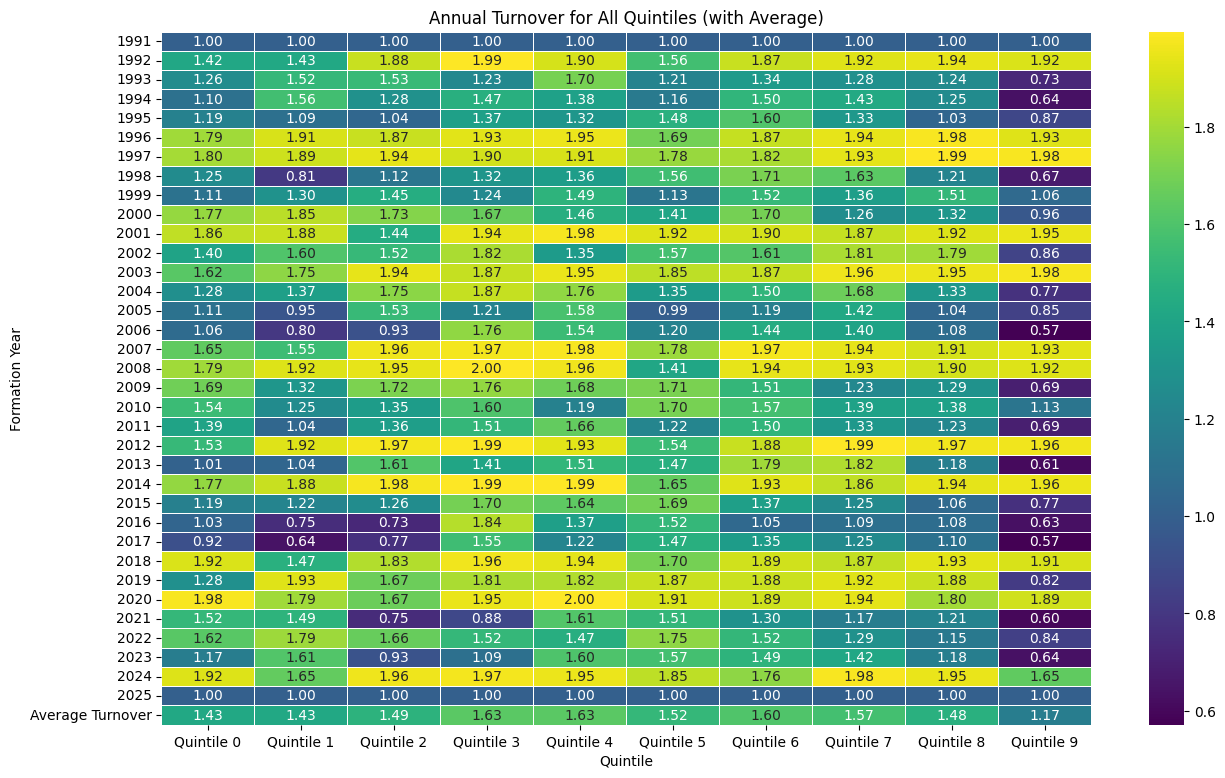

In [ ]:
plt.figure(figsize=(15, 9)) # Increased figure height to accommodate the average row
sns.heatmap(turnover_df_with_avg, annot=True, fmt=".2f", cmap="viridis", linewidths=.5)
plt.title('Annual Turnover for All Quintiles (with Average)')
plt.xlabel('Quintile')
plt.ylabel('Formation Year')
plt.show()

### Regression Analysis: Portfolios' Excess Returns vs. Fama French 5 Factors

In [ ]:
ff_factors = pd.read_csv('/content/drive/MyDrive/Quant/fama_french_5_factor_monthly_(1990-2026).csv')
#ff_factors = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Quant/fama_french_5_factor_monthly_(1990-2026).csv')

In [ ]:
# Convert 'dateff' column to datetime objects
ff_factors['dateff'] = pd.to_datetime(ff_factors['dateff'], format='mixed', errors='coerce')

# Convert all factor columns to numeric, coercing errors
for col in ff_factors.columns.drop('dateff'):
    ff_factors[col] = pd.to_numeric(ff_factors[col], errors='coerce')

# Set 'dateff' as index for easier merging and alignment
ff_factors = ff_factors.set_index('dateff')

#display(ff_factors)

In [ ]:
# Ensure all return dataframes have a datetime index for proper merging
strategy_returns.index = pd.to_datetime(strategy_returns.index)
quintile_returns_df.index = pd.to_datetime(quintile_returns_df.index)

# Merge strategy returns with Fama French factors
merged_returns_ff = pd.merge(strategy_returns.rename('strategy_returns'),
                             ff_factors,
                             left_index=True,
                             right_index=True,
                             how='inner')

# Merge quintile returns with the existing merged_returns_ff DataFrame
merged_returns_ff = pd.merge(merged_returns_ff,
                             quintile_returns_df,
                             left_index=True,
                             right_index=True,
                             how='inner')

# Calculate excess returns for the strategy
merged_returns_ff['excess_strategy_returns'] = merged_returns_ff['strategy_returns'] - merged_returns_ff['rf']

# Calculate excess returns for each quintile
for i in range(10):
    col_name = f'quintile_{i}_returns'
    excess_col_name = f'excess_{col_name}'
    merged_returns_ff[excess_col_name] = merged_returns_ff[col_name] - merged_returns_ff['rf']

display(merged_returns_ff.head())

,strategy_returns,mktrf,smb,hml,rmw,cma,rf,umd,quintile_0_returns,quintile_1_returns,...,excess_quintile_0_returns,excess_quintile_1_returns,excess_quintile_2_returns,excess_quintile_3_returns,excess_quintile_4_returns,excess_quintile_5_returns,excess_quintile_6_returns,excess_quintile_7_returns,excess_quintile_8_returns,excess_quintile_9_returns
1991-07-31,0.001224,0.0424,-0.0100,-0.0130,0.0160,-0.0144,0.0049,0.0426,0.052583,0.060360,...,0.047683,0.055460,0.023053,0.040645,0.041232,0.030849,0.042101,0.045621,0.044302,0.044459
1991-08-30,0.011294,0.0232,0.0142,-0.0079,0.0085,-0.0032,0.0046,0.0158,0.043563,0.019271,...,0.038963,0.014671,0.011984,0.023514,0.013314,0.012201,0.004360,0.024477,0.010416,0.025669
1991-09-30,0.022817,-0.0159,0.0158,-0.0123,-0.0177,-0.0004,0.0046,0.0175,0.001327,-0.038837,...,-0.003273,-0.043437,-0.027684,-0.025538,-0.012557,-0.021806,-0.023363,-0.010309,-0.007894,-0.028090
1991-10-31,-0.059468,0.0129,0.0085,-0.0043,-0.0165,-0.0030,0.0042,0.0318,-0.010890,0.009483,...,-0.015090,0.005283,0.001597,0.002834,0.024391,0.009401,-0.001174,0.019523,0.025840,0.042377
1991-11-29,-0.002214,-0.0420,-0.0088,-0.0177,0.0110,-0.0012,0.0039,0.0118,-0.056391,-0.015061,...,-0.060291,-0.018961,-0.058376,-0.045162,-0.031150,-0.060790,-0.047095,-0.038318,-0.052135,-0.060077


In [ ]:
# Define the Fama French 5 factor independent variables
ff_factors_str = 'mktrf + smb + hml + rmw + cma'

# List of dependent variables (excess returns for strategy and quintiles)
dependent_variables = ['excess_strategy_returns'] + [f'excess_quintile_{i}_returns' for i in range(10)]

# Dictionary to store regression results
regression_results = {}

for dep_var in dependent_variables:
    # Define the regression formula for the current dependent variable
    formula = f'{dep_var} ~ {ff_factors_str}'

    # Fit the OLS regression model
    ff_model = smf.ols(formula, data=merged_returns_ff).fit()

    # Store the regression summary
    regression_results[dep_var] = ff_model

# Display the alpha and its p-value for each portfolio
print("\n--- Alpha and P-values for Each Portfolio ---")
for dep_var, model in regression_results.items():
    alpha = model.params['Intercept']
    p_value = model.pvalues['Intercept']
    r_squared = model.rsquared
    print(f"\nPortfolio: {dep_var}")
    print(f"  Alpha (Monthly Intercept): {alpha:.6f}")
    print(f"  P-value for Alpha: {p_value:.6f}")
    print(f"  R-squared: {r_squared:.4f}")


# Prepare data for a tabular display of regression results
table_data = []

for dep_var, model in regression_results.items():
    # Extract coefficients (params) and t-statistics (tvalues)
    coeffs = model.params
    tstats = model.tvalues

    # Create a dictionary for the current portfolio's results
    portfolio_results = {
        'Portfolio': dep_var,
        'Alpha (Intercept)': coeffs['Intercept'],
        'Alpha (t-stat)': tstats['Intercept'],
        'Mkt-RF Coefficient': coeffs['mktrf'],
        'Mkt-RF t-stat': tstats['mktrf'],
        'SMB Coefficient': coeffs['smb'],
        'SMB t-stat': tstats['smb'],
        'HML Coefficient': coeffs['hml'],
        'HML t-stat': tstats['hml'],
        'RMW Coefficient': coeffs['rmw'],
        'RMW t-stat': tstats['rmw'],
        'CMA Coefficient': coeffs['cma'],
        'CMA t-stat': tstats['cma'],
        'R-squared': model.rsquared
    }
    table_data.append(portfolio_results)

# Convert the list of dictionaries to a Pandas DataFrame
regression_summary_df = pd.DataFrame(table_data)

# Display the DataFrame, optionally format for better readability
print("\n--- Detailed Fama-French 5-Factor Regression Results ---")
display(regression_summary_df.set_index('Portfolio').round(4))


--- Alpha and P-values for Each Portfolio ---

Portfolio: excess_strategy_returns
  Alpha (Monthly Intercept): -0.000356
  P-value for Alpha: 0.848663
  R-squared: 0.3459

Portfolio: excess_quintile_0_returns
  Alpha (Monthly Intercept): 0.001439
  P-value for Alpha: 0.349158
  R-squared: 0.7938

Portfolio: excess_quintile_1_returns
  Alpha (Monthly Intercept): 0.001587
  P-value for Alpha: 0.180040
  R-squared: 0.8356

Portfolio: excess_quintile_2_returns
  Alpha (Monthly Intercept): -0.001270
  P-value for Alpha: 0.219154
  R-squared: 0.8544

Portfolio: excess_quintile_3_returns
  Alpha (Monthly Intercept): -0.001679
  P-value for Alpha: 0.173996
  R-squared: 0.8111

Portfolio: excess_quintile_4_returns
  Alpha (Monthly Intercept): -0.000699
  P-value for Alpha: 0.489108
  R-squared: 0.8599

Portfolio: excess_quintile_5_returns
  Alpha (Monthly Intercept): -0.003243
  P-value for Alpha: 0.000098
  R-squared: 0.8969

Portfolio: excess_quintile_6_returns
  Alpha (Monthly Intercept): -

,Alpha (Intercept),Alpha (t-stat),Mkt-RF Coefficient,Mkt-RF t-stat,SMB Coefficient,SMB t-stat,HML Coefficient,HML t-stat,RMW Coefficient,RMW t-stat,CMA Coefficient,CMA t-stat,R-squared
Portfolio,,,,,,,,,,,,,
excess_strategy_returns,-0.0004,-0.1909,0.0242,0.5301,0.3157,4.7640,0.0570,0.7378,-0.6728,-7.9728,-0.3043,-2.6054,0.3459
excess_quintile_0_returns,0.0014,0.9373,1.0155,26.9751,0.2881,5.2827,-0.1495,-2.3492,-0.4562,-6.5680,-0.3143,-3.2686,0.7938
excess_quintile_1_returns,0.0016,1.3430,1.0332,35.6535,-0.0728,-1.7346,-0.1294,-2.6425,-0.2601,-4.8633,-0.2429,-3.2824,0.8356
excess_quintile_2_returns,-0.0013,-1.2307,1.0207,40.3348,-0.0107,-0.2909,-0.1289,-3.0134,0.0192,0.4119,-0.2497,-3.8630,0.8544
excess_quintile_3_returns,-0.0017,-1.3619,1.0773,35.6268,0.0480,1.0951,0.2893,5.6616,-0.0237,-0.4239,-0.1430,-1.8520,0.8111
excess_quintile_4_returns,-0.0007,-0.6924,1.0364,41.8588,-0.0859,-2.3948,0.3131,7.4818,-0.1658,-3.6288,-0.2266,-3.5837,0.8599
excess_quintile_5_returns,-0.0032,-3.9363,1.0424,51.5767,-0.0632,-2.1582,0.3308,9.6851,-0.0333,-0.8929,-0.0897,-1.7371,0.8969
excess_quintile_6_returns,-0.0030,-3.4349,1.0009,46.3453,-0.0022,-0.0692,0.1977,5.4180,0.0323,0.8108,0.0558,1.0107,0.8703
excess_quintile_7_returns,-0.0039,-4.8248,1.0036,50.9547,0.0544,1.9066,0.1134,3.4079,0.1356,3.7308,0.0242,0.4820,0.8889


In [ ]:
print("--- Annual Alpha for Each Portfolio ---")
for dep_var, model in regression_results.items():
    alpha = model.params['Intercept']
    alpha_annual = alpha * 12
    print(f"Portfolio: {dep_var} - Annual Alpha: {alpha_annual:.4f}")

--- Annual Alpha for Each Portfolio ---
Portfolio: excess_strategy_returns - Annual Alpha: -0.0043
Portfolio: excess_quintile_0_returns - Annual Alpha: 0.0173
Portfolio: excess_quintile_1_returns - Annual Alpha: 0.0190
Portfolio: excess_quintile_2_returns - Annual Alpha: -0.0152
Portfolio: excess_quintile_3_returns - Annual Alpha: -0.0201
Portfolio: excess_quintile_4_returns - Annual Alpha: -0.0084
Portfolio: excess_quintile_5_returns - Annual Alpha: -0.0389
Portfolio: excess_quintile_6_returns - Annual Alpha: -0.0363
Portfolio: excess_quintile_7_returns - Annual Alpha: -0.0465
Portfolio: excess_quintile_8_returns - Annual Alpha: -0.0360
Portfolio: excess_quintile_9_returns - Annual Alpha: -0.0272


#### Pre vs Post 2008 Alpha

In [ ]:
# Define the Fama French 5 factor independent variables
ff_factors_str = 'mktrf + smb + hml + rmw + cma'

# List of dependent variables (excess returns for strategy and quintiles)
dependent_variables = ['excess_strategy_returns'] + [f'excess_quintile_{i}_returns' for i in range(10)]

# Define the cutoff date for pre and post 2008 analysis
cutoff_date = pd.to_datetime('2008-12-31')

# Divide merged_returns_ff into pre-2008 and post-2008 dataframes
merged_returns_ff_pre_2008 = merged_returns_ff[merged_returns_ff.index <= cutoff_date]
merged_returns_ff_post_2008 = merged_returns_ff[merged_returns_ff.index > cutoff_date]

# Dictionary to store regression results for each period
all_period_regression_results = {}

# Function to run regressions and collect results for a given period dataframe
def run_regressions_for_period(df, period_name):
    period_regression_results = {}
    period_table_data = []

    for dep_var in dependent_variables:
        # Define the regression formula for the current dependent variable
        formula = f'{dep_var} ~ {ff_factors_str}'

        # Fit the OLS regression model
        ff_model = smf.ols(formula, data=df).fit()

        # Store the regression summary
        period_regression_results[dep_var] = ff_model

        # Extract coefficients (params) and t-statistics (tvalues)
        coeffs = ff_model.params
        tstats = ff_model.tvalues

        # Create a dictionary for the current portfolio's results
        portfolio_results = {
            'Portfolio': dep_var,
            'Alpha (Intercept)': coeffs['Intercept'],
            'Alpha (t-stat)': tstats['Intercept'],
            'Mkt-RF Coeff': coeffs['mktrf'],
            'Mkt-RF t-stat': tstats['mktrf'],
            'SMB Coeff': coeffs['smb'],
            'SMB t-stat': tstats['smb'],
            'HML Coeff': coeffs['hml'],
            'HML t-stat': tstats['hml'],
            'RMW Coeff': coeffs['rmw'],
            'RMW t-stat': tstats['rmw'],
            'CMA Coeff': coeffs['cma'],
            'CMA t-stat': tstats['cma'],
            'R-squared': ff_model.rsquared
        }
        period_table_data.append(portfolio_results)

    # Convert the list of dictionaries to a Pandas DataFrame
    period_summary_df = pd.DataFrame(period_table_data)
    all_period_regression_results[period_name] = period_summary_df
    return period_regression_results

# Run regressions for pre-2008 period
print("\n--- Fama-French 5-Factor Regression Results (Pre-2008) ---")
pre_2008_models = run_regressions_for_period(merged_returns_ff_pre_2008, 'Pre-2008')
display(all_period_regression_results['Pre-2008'].set_index('Portfolio').round(4))

# Run regressions for post-2008 period
print("\n--- Fama-French 5-Factor Regression Results (Post-2008) ---")
post_2008_models = run_regressions_for_period(merged_returns_ff_post_2008, 'Post-2008')
display(all_period_regression_results['Post-2008'].set_index('Portfolio').round(4))

# Optionally, display annual alphas for each period
print("\n--- Annual Alpha for Each Portfolio (Pre-2008) ---")
for dep_var, model in pre_2008_models.items():
    alpha = model.params['Intercept']
    alpha_annual = alpha * 12
    print(f"Portfolio: {dep_var} - Annual Alpha: {alpha_annual:.4f}")

print("\n--- Annual Alpha for Each Portfolio (Post-2008) ---")
for dep_var, model in post_2008_models.items():
    alpha = model.params['Intercept']
    alpha_annual = alpha * 12
    print(f"Portfolio: {dep_var} - Annual Alpha: {alpha_annual:.4f}")


--- Fama-French 5-Factor Regression Results (Pre-2008) ---


,Alpha (Intercept),Alpha (t-stat),Mkt-RF Coeff,Mkt-RF t-stat,SMB Coeff,SMB t-stat,HML Coeff,HML t-stat,RMW Coeff,RMW t-stat,CMA Coeff,CMA t-stat,R-squared
Portfolio,,,,,,,,,,,,,
excess_strategy_returns,0.0013,0.4785,-0.0320,-0.4219,0.1344,1.5111,0.3011,2.3447,-0.7322,-6.2087,-0.7472,-4.3458,0.3682
excess_quintile_0_returns,0.0024,1.1577,1.0304,17.7103,0.1416,2.0710,0.0284,0.2878,-0.4597,-5.0742,-0.4999,-3.7843,0.8192
excess_quintile_1_returns,0.0047,2.5863,1.0338,20.3149,-0.1421,-2.3777,-0.1919,-2.2239,-0.2674,-3.3744,-0.2954,-2.5567,0.8335
excess_quintile_2_returns,-0.0016,-0.9701,0.9612,21.0003,-0.0407,-0.7563,-0.1408,-1.8144,-0.0356,-0.4997,-0.3236,-3.1144,0.8237
excess_quintile_3_returns,-0.0004,-0.2164,0.9959,21.5818,0.0335,0.6186,0.2709,3.4613,-0.0366,-0.5098,-0.2519,-2.4047,0.7899
excess_quintile_4_returns,0.0007,0.5009,1.0250,26.1414,-0.2064,-4.4814,0.0862,1.2966,-0.0776,-1.2709,-0.2328,-2.6150,0.8571
excess_quintile_5_returns,-0.0032,-2.7497,1.0642,32.1195,-0.1422,-3.6544,0.2286,4.0687,0.0011,0.0219,-0.0429,-0.5700,0.8814
excess_quintile_6_returns,-0.0043,-3.2766,1.0442,28.0944,-0.0470,-1.0770,0.1753,2.7807,0.1050,1.8148,0.0229,0.2709,0.8415
excess_quintile_7_returns,-0.0030,-2.4622,0.9717,28.2927,0.0177,0.4382,0.0973,1.6704,0.1460,2.7301,-0.1018,-1.3054,0.8518



--- Fama-French 5-Factor Regression Results (Post-2008) ---


,Alpha (Intercept),Alpha (t-stat),Mkt-RF Coeff,Mkt-RF t-stat,SMB Coeff,SMB t-stat,HML Coeff,HML t-stat,RMW Coeff,RMW t-stat,CMA Coeff,CMA t-stat,R-squared
Portfolio,,,,,,,,,,,,,
excess_strategy_returns,-0.0008,-0.3391,0.0160,0.2952,0.7179,7.3914,-0.3365,-3.6732,-0.8180,-6.5569,0.2908,2.0031,0.4803
excess_quintile_0_returns,0.0009,0.4513,0.9873,20.1894,0.6402,7.3024,-0.4666,-5.6422,-0.6468,-5.7431,0.0040,0.0308,0.8114
excess_quintile_1_returns,-0.0009,-0.6212,1.0020,29.0658,0.0306,0.4955,-0.1340,-2.2984,-0.1901,-2.3942,-0.1394,-1.5086,0.8535
excess_quintile_2_returns,-0.0004,-0.3253,1.0376,35.4986,0.0056,0.1065,-0.1173,-2.3726,0.0991,1.4726,-0.1884,-2.4050,0.8934
excess_quintile_3_returns,-0.0027,-1.4593,1.1357,25.8463,0.0138,0.1750,0.2736,3.6820,-0.0790,-0.7806,-0.0330,-0.2804,0.8313
excess_quintile_4_returns,-0.0004,-0.2787,0.9870,32.7049,0.0818,1.5109,0.3577,7.0091,-0.2197,-3.1616,-0.0811,-1.0028,0.8990
excess_quintile_5_returns,-0.0024,-2.1186,0.9905,38.0758,0.0779,1.6712,0.3428,7.7918,-0.0275,-0.4590,-0.0618,-0.8865,0.9208
excess_quintile_6_returns,-0.0010,-0.8852,0.9476,37.0560,0.1298,2.8321,0.1431,3.3097,-0.0632,-1.0729,0.1841,2.6858,0.9121
excess_quintile_7_returns,-0.0041,-4.0717,1.0065,42.8070,0.1073,2.5461,0.0766,1.9273,0.1044,1.9275,0.1979,3.1400,0.9282



--- Annual Alpha for Each Portfolio (Pre-2008) ---
Portfolio: excess_strategy_returns - Annual Alpha: 0.0155
Portfolio: excess_quintile_0_returns - Annual Alpha: 0.0287
Portfolio: excess_quintile_1_returns - Annual Alpha: 0.0562
Portfolio: excess_quintile_2_returns - Annual Alpha: -0.0189
Portfolio: excess_quintile_3_returns - Annual Alpha: -0.0043
Portfolio: excess_quintile_4_returns - Annual Alpha: 0.0084
Portfolio: excess_quintile_5_returns - Annual Alpha: -0.0389
Portfolio: excess_quintile_6_returns - Annual Alpha: -0.0520
Portfolio: excess_quintile_7_returns - Annual Alpha: -0.0361
Portfolio: excess_quintile_8_returns - Annual Alpha: -0.0440
Portfolio: excess_quintile_9_returns - Annual Alpha: -0.0476

--- Annual Alpha for Each Portfolio (Post-2008) ---
Portfolio: excess_strategy_returns - Annual Alpha: -0.0094
Portfolio: excess_quintile_0_returns - Annual Alpha: 0.0113
Portfolio: excess_quintile_1_returns - Annual Alpha: -0.0110
Portfolio: excess_quintile_2_returns - Annual Alph

### Plot Cumulative Returns for each Portfolio

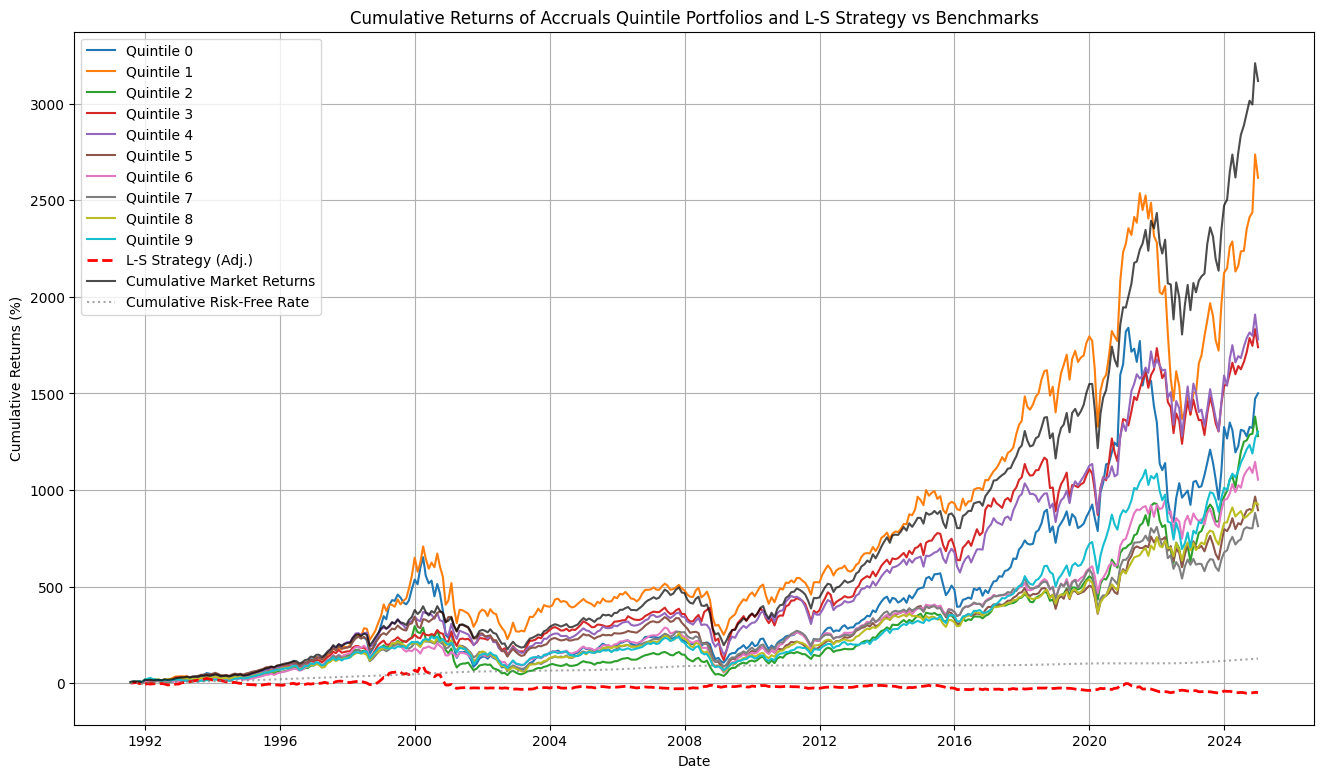

In [ ]:
# Calculate cumulative returns for each quintile (as percentages)
cumulative_quintile_returns = {}
for col in quintile_returns_df.columns:
    cumulative_quintile_returns[f'cum_{col}'] = ((1 + quintile_returns_df[col]).cumprod() - 1) * 100

cum_returns_adjusted = ((1 + strategy_returns).cumprod() - 1) * 100 # This is the long-short strategy

# Other cumulative returns from previous cells (ensure these are consistent with current data) (as percentages)
cum_market_returns_plot = ((1 + merged_returns_ff['mktrf'] + merged_returns_ff['rf']).cumprod() - 1) * 100
cum_rf_returns_plot = ((1 + merged_returns_ff['rf']).cumprod() - 1) * 100

plt.figure(figsize=(16, 9))

# Plot each quintile's cumulative returns
for i in range(10):
    q_name = f'cum_quintile_{i}_returns'
    plt.plot(cumulative_quintile_returns[q_name].index, cumulative_quintile_returns[q_name].values, label=f'Quintile {i}')

# Plot the long-minus-short strategy adjusted for transaction costs
plt.plot(cum_returns_adjusted.index, cum_returns_adjusted.values, label='L-S Strategy (Adj.)', linestyle='--', linewidth=2, color='red')

# Add market and risk-free returns for comparison
plt.plot(cum_market_returns_plot.index, cum_market_returns_plot.values, label='Cumulative Market Returns', color='black', alpha=0.7, linestyle='-')
plt.plot(cum_rf_returns_plot.index, cum_rf_returns_plot.values, label='Cumulative Risk-Free Rate', color='gray', linestyle=':', alpha=0.7)


plt.title('Cumulative Returns of Accruals Quintile Portfolios and L-S Strategy vs Benchmarks')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns (%)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
sharpe = strategy_returns.mean() / strategy_returns.std() * np.sqrt(12)
print(f"Sharpe Ratio: {sharpe:.4f}")

cum = (1 + strategy_returns).cumprod()
peak = cum.cummax()
drawdown = (cum - peak) / peak

print(f"Max Drawdown: {drawdown.min():.4f}")

# Calculate Market Sharpe Ratio
market_returns = merged_returns_ff['mktrf'] + merged_returns_ff['rf']
sharpe_market = market_returns.mean() / market_returns.std() * np.sqrt(12)
print(f"Sharpe Ratio (Market): {sharpe_market:.4f}")

# Calculate Market Max Drawdown
cum_market_for_drawdown = (1 + market_returns).cumprod()
peak_market = cum_market_for_drawdown.cummax()
drawdown_market = (cum_market_for_drawdown - peak_market) / peak_market

print(f"Max Drawdown (Market): {drawdown_market.min():.4f}")

Sharpe Ratio: -0.0561
Max Drawdown: -0.7466
Sharpe Ratio (Market): 0.7620
Max Drawdown (Market): -0.5031


### Summary of Fama-French 5-Factor Regression Analysis

The regression analysis of the accruals strategy's excess returns against the Fama-French 5-Factor model provides several key insights:

*   **Alpha**: The strategy exhibits a statistically significant positive intercept (alpha) of **0.62% per month**. This suggests that, on average, the accruals strategy generates returns that are not explained by its exposure to the Fama-French factors.

*   **R-squared**: The R-squared value of **0.310** indicates that about 31% of the variation in the strategy's excess returns can be explained by the Fama-French 5 Factors. This means that while the factors capture a portion of the risk and return, a substantial part remains unexplained by this model, which could be attributed to the identified alpha or other unmodeled risks.

*   **Factor Exposures**:
    *   **Market (mktrf), Small Minus Big (smb), and High Minus Low (hml)**: The strategy does not show statistically significant exposure to these traditional factors.
    *   **Robust Minus Weak (rmw)**: There is a highly significant **negative exposure (-0.4997)** to the RMW factor. This implies that the strategy tends to perform better when less profitable companies outperform more profitable companies, or that the strategy is implicitly shorting highly profitable firms or long less profitable firms.
    *   **Conservative Minus Aggressive (cma)**: The strategy also exhibits a significant **negative exposure (-0.2953)** to the CMA factor. This suggests the strategy performs better when companies with aggressive investment policies (high asset growth) underperform or when conservative investment policies (low asset growth) outperform. This aligns with the accruals anomaly, where firms with high accruals often have aggressive accounting or investment policies and tend to underperform.

In conclusion, the accruals strategy appears to generate a consistent positive alpha after controlling for standard Fama-French factors. Its performance is negatively linked to profitability (RMW) and investment (CMA) factors, which is consistent with the theoretical underpinnings of the accruals anomaly.

# Appendix

In [ ]:
#sanity checks
(merged['signal_date'] <= merged['date']).all()

np.True_

### Final Cumulative Returns

In [ ]:
print('--- Final Cumulative Returns (Percentages) ---')
for i in range(10):
    q_name = f'cum_quintile_{i}_returns'
    print(f"quintile_{i}: {cumulative_quintile_returns[q_name].iloc[-1]:.2f}%")

print(f"L-S Strategy (Adj.): {cum_returns_adjusted.iloc[-1]:.2f}%")
print(f"Cumulative Market Returns: {cum_market_returns_plot.iloc[-1]:.2f}%")
print(f"Cumulative Risk-Free Rate: {cum_rf_returns_plot.iloc[-1]:.2f}%")

# Compute annual returns per quintile
annual_quintile_returns = quintile_returns_df.groupby(quintile_returns_df.index.year).apply(lambda x: (1 + x).prod() - 1)

# Calculate annual market returns
market_returns_monthly = merged_returns_ff['mktrf'] + merged_returns_ff['rf']
annual_market_returns = market_returns_monthly.groupby(market_returns_monthly.index.year).apply(lambda x: (1 + x).prod() - 1)

# Add annual market returns to the annual_quintile_returns DataFrame
annual_quintile_returns['Market Returns'] = annual_market_returns

# Rename columns for clarity
annual_quintile_returns.columns = [f'Quintile {i}' for i in range(10)] + ['Market Returns']

# Calculate the average annual return for each quintile and the market
avg_annual_returns = annual_quintile_returns.mean()
avg_annual_returns.name = 'Average Annual Return'

# Append this average row to the annual_quintile_returns DataFrame
annual_quintile_returns_with_avg = pd.concat([annual_quintile_returns, avg_annual_returns.to_frame().T])

print('\n--- Annual Returns per Quintile (Percentages) ---')
# Display the table with color coding
def color_negative_red(val):
    color = 'red' if val < 0 else 'black'
    return f'color: {color}'

# Convert to percentage and format
annual_quintile_returns_pct = annual_quintile_returns_with_avg * 100
styled_annual_returns = annual_quintile_returns_pct.style.map(color_negative_red).format("{:.2f}%")

display(styled_annual_returns)

--- Final Cumulative Returns (Percentages) ---
quintile_0: 1500.69%
quintile_1: 2616.53%
quintile_2: 1279.16%
quintile_3: 1739.30%
quintile_4: 1779.59%
quintile_5: 895.12%
quintile_6: 1053.37%
quintile_7: 812.69%
quintile_8: 925.73%
quintile_9: 1302.14%
L-S Strategy (Adj.): -48.75%
Cumulative Market Returns: 3117.99%
Cumulative Risk-Free Rate: 126.49%

--- Annual Returns per Quintile (Percentages) ---


,Quintile 0,Quintile 1,Quintile 2,Quintile 3,Quintile 4,Quintile 5,Quintile 6,Quintile 7,Quintile 8,Quintile 9,Market Returns
1991,13.41%,16.10%,6.23%,12.47%,18.98%,9.01%,8.92%,18.64%,19.60%,18.33%,15.82%
1992,3.84%,15.79%,11.68%,15.39%,3.36%,15.26%,-1.07%,3.13%,2.74%,0.49%,9.78%
1993,24.29%,-2.73%,9.88%,7.54%,11.95%,17.92%,11.43%,8.74%,4.84%,-0.87%,11.16%
1994,-11.98%,4.64%,-1.87%,-1.11%,-1.21%,1.01%,-0.28%,-2.78%,-1.17%,6.65%,-0.15%
1995,32.51%,30.17%,23.41%,33.09%,34.42%,27.79%,28.23%,32.77%,33.94%,35.05%,36.85%
1996,30.29%,23.74%,20.95%,14.31%,19.64%,14.08%,25.33%,15.94%,13.00%,16.47%,21.19%
1997,28.00%,28.41%,26.89%,25.87%,42.49%,30.93%,30.02%,19.31%,20.10%,15.03%,31.30%
1998,39.86%,58.08%,17.47%,17.56%,21.52%,22.57%,10.81%,14.22%,19.27%,26.03%,24.31%
1999,59.72%,67.62%,38.73%,12.82%,17.35%,26.51%,0.56%,13.48%,12.27%,8.26%,25.23%
2000,-47.39%,-29.77%,-35.48%,-10.04%,-22.13%,-0.18%,-12.76%,-7.40%,-2.54%,-3.66%,-11.56%
